# 03 · Modelo #101 — Segmentación de pensionados por consumo

**Caso de uso 5** (Análisis y segmentos) · **Sector:** Retail y Banca · **Analítica:** Clustering ·
**Solo ACH:** Sí
**Metodología:** CRISP-DM · Fases 3–4 · **Depende de:** `00_EDA_Preparacion_Datos.ipynb`

### Objetivo de negocio
Los pensionados son un segmento comercialmente atractivo y mal atendido: ingreso **fijo, mensual y
verificable** (la mesada), baja rotación y alta sensibilidad al precio y al servicio. Este modelo los
identifica dentro de los datos de ACH y los agrupa por **cómo consumen**, para que:

- una **AFP / administradora de pensiones** (Colpensiones, Porvenir) entienda la vida financiera de su
  mesada después de pagarla;
- un **retailer** (Grupo Éxito, Cencosud Colombia) sepa qué perfil de pensionado ya le compra y cuál no;
- una **caja de compensación** (Compensar, Colsubsidio, Cafam) dimensione su base pensionada y su gasto;
- un **banco** (Bancolombia, Davivienda) diseñe productos de renta, salud y crédito de bajo riesgo sobre
  un ingreso que puede verificar.

**Empresas objetivo:** Colpensiones · Porvenir AFP · Grupo Éxito · Cencosud Colombia · Bancolombia ·
Davivienda · Compensar · Colsubsidio · Cafam.

### Cómo se construye
1. **Identificación** del pensionado con la evidencia formal de PILA (relación laboral, planilla y tipo de
   aportante) — no con un proxy conductual.
2. **Caracterización** de la mesada: pagador (Colpensiones / AFP / aseguradora / fondo público) y régimen.
3. **Features de consumo** sobre la ventana común 2025-01 → 2026-06 (18 meses): RFM, ticket, regularidad,
   composición del gasto por categoría, tasa de consumo sobre la mesada y penetración de entidades objetivo.
4. **Clustering** comparando K-Means, jerárquico (Ward) y DBSCAN; k por codo, silueta y Davies-Bouldin.

> ⚠️ **Limitaciones declaradas desde el inicio.** (1) El universo de pensionados observable en estos
> extractos es **pequeño** (cientos, no miles): los resultados son direccionales y no censales.
> (2) Transferencias y PSE están truncados en el tope de Excel. (3) Los datos son **mensuales**: no hay
> día de la transacción, así que el efecto "día de pago de la mesada" **no es medible** y se sustituye por
> proxies de ritmo mensual (regularidad y concentración). (4) Sin campo de ubicación, no hay capa
> geográfica.

## 1 · Configuración

Librerías, semilla única (`SEMILLA = 42`) para reproducibilidad y estilo gráfico común del proyecto.
La capa de ingeniería de datos (`ach_pipeline`) resuelve carga, llave de persona, taxonomía de comercios y
tablas persona × mes; este notebook solo hace ciencia de datos sobre esa base.

In [1]:
import sys
import unicodedata
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score,
                             silhouette_score)
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd()
if not (ROOT / "scripts").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))
import ach_pipeline as ap   # noqa: E402

SEMILLA = 42
VENTANA = ("2025-01", "2026-06")   # ventana común a las 3 fuentes
N_MESES = 18                        # meses de la ventana

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (11, 4.2),
                     "axes.titlesize": 12, "axes.titleweight": "bold",
                     "axes.labelsize": 10, "legend.frameon": False})
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Paleta fija del proyecto (no ciclar: el orden es semántico)
AZUL, VERDE, NARANJA, MORADO, ROJO, GRIS = "#4c72b0", "#55a868", "#dd8452", "#8172b3", "#c44e52", "#8c8c8c"
cop = mticker.FuncFormatter(lambda x, _: f"${x/1e6:,.1f}M")
mil = mticker.FuncFormatter(lambda x, _: f"{x/1e3:,.0f}k")
print(f"Listo · pandas {pd.__version__} · semilla {SEMILLA} · ventana {VENTANA[0]} a {VENTANA[1]}")

Listo · pandas 2.3.3 · semilla 42 · ventana 2025-01 a 2026-06


## 2 · Población objetivo: ¿quién es pensionado en los datos de ACH?

**Objetivo técnico.** Aislar a los pensionados sin ambigüedad. Se usa la evidencia **formal** de
Seguridad Social (PILA), que trae tres marcadores independientes y concordantes:

| Campo | Marcador de pensionado |
|---|---|
| `Relación laboral` | contiene *"Pensionado…"* (prima media, ahorro individual, riesgos profesionales, por el empleador) |
| `Tipo planilla` | `P` — planilla de pensionados |
| `Tipo aportante` | `PAGADOR DE PENSIONES` / `ADMINISTRADORA DE PENSIONES` |

**Interpretación de negocio.** El pensionado sigue cotizando salud sobre su mesada, y quien paga esa
cotización es su pagador de pensión. Por eso PILA lo ve aunque ya no trabaje: es la única fuente de las
tres que certifica la condición de pensionado. La regla es **inclusiva** (basta un marcador) porque los
tres apuntan al mismo hecho y ninguno está siempre presente.

In [2]:
ss_raw = ap.add_person_key(ap.load_raw("ss").drop_duplicates(), "ss")

rel  = ss_raw["Relación laboral"].astype("string").str.upper()
plan = ss_raw["Tipo planilla"].astype("string").str.upper()
tapo = ss_raw["Tipo aportante"].astype("string").str.upper()

def _bool(serie) -> np.ndarray:
    """Máscara booleana pura (las columnas string traen NA, que no sirve para indexar)."""
    return serie.fillna(False).to_numpy(dtype=bool)


marcador_rel  = _bool(rel.str.contains("PENSIONADO", na=False))
marcador_plan = _bool(plan.eq("P"))
marcador_apo  = _bool(tapo.str.contains("PENSIONES", na=False))
es_fila_pension = marcador_rel | marcador_plan | marcador_apo

marcadores = {
    "Relación laboral = Pensionado": marcador_rel,
    "Tipo planilla = P": marcador_plan,
    "Tipo aportante = pagador/administradora de pensiones": marcador_apo,
}
resumen_marcadores = pd.DataFrame(
    {"filas": [int(m.sum()) for m in marcadores.values()],
     "personas": [ss_raw.loc[m, "person_id"].nunique() for m in marcadores.values()]},
    index=list(marcadores))
resumen_marcadores.loc["UNIÓN (regla aplicada)"] = [int(es_fila_pension.sum()),
                                                    ss_raw.loc[es_fila_pension, "person_id"].nunique()]
display(resumen_marcadores)

pensionados = set(ss_raw.loc[es_fila_pension, "person_id"].dropna())
print(f"Personas con evidencia de pensión en PILA : {len(pensionados):,}")
print(f"Universo de personas en Seguridad Social   : {ss_raw['person_id'].nunique():,}"
      f"  ({len(pensionados) / ss_raw['person_id'].nunique() * 100:.1f}% son pensionados)")

,filas,personas
Relación laboral = Pensionado,9662,583
Tipo planilla = P,7866,452
Tipo aportante = pagador/administradora de pensiones,9463,483
UNIÓN (regla aplicada),9662,583


Personas con evidencia de pensión en PILA : 583
Universo de personas en Seguridad Social   : 33,281  (1.8% son pensionados)


### 2.1 · La mesada: quién la paga y bajo qué régimen

**Objetivo técnico.** Del bloque de aportante de PILA se extrae el **pagador de la mesada** (`Razón social`,
ofuscada en sus últimos caracteres) y el **régimen pensional** (del texto de `Relación laboral`). El valor
de la mesada se aproxima con la mediana del **IBC de salud** de los meses en condición de pensionado: el
pensionado cotiza salud *sobre* su mesada, así que ese IBC **es** la mesada declarada.

**Interpretación de negocio.** Esto conecta el modelo con dos de las empresas objetivo — **Colpensiones**
(régimen de prima media) y **Porvenir** (ahorro individual) — y separa a quien recibe una **renta vitalicia
de aseguradora** (Bolívar, Suramericana, BBVA Seguros, Positiva…), un perfil de riesgo y de producto
distinto.

In [3]:
CATALOGO_PAGADOR = {
    "Colpensiones":            ["ADMINISTRADORA COLOMBIANA DE PENSIONES"],
    "Porvenir":                ["PORV"],
    "Protección":              ["FONDO DE PENSIONES OBLIGATORIAS PROTECCION", "PROTECCION"],
    "Colfondos":               ["FONDO DE PENSIONES OBLIGATORIAS COLFONDOS", "COLFONDOS"],
    "Skandia":                 ["SKANDIA"],
    "Consorcio FOPEP":         ["CONSORCIO FO"],
    "Aseguradora (renta vitalicia)": ["SEGUROS", "COMPANIA SEGUROS", "POSITIVA", "ASULADO", "MAPFRE",
                                      "AXA COLPATRIA", "LA EQUIDAD", "COLMENA", "BBVA SEGUROS"],
    "Fondo público / especial": ["FONDO DE PASIVO SOCIAL", "FONDO DE PREVISION", "FIDUPREV",
                                 "FIDECOMISOS PATRIMONIOS AUTONOMOS", "FIDUCIARIA"],
}


def clasificar_pagador(nombre: str) -> str:
    """Pagador de la mesada a partir del prefijo visible de la razón social."""
    n = str(nombre).upper()
    for etiqueta, claves in CATALOGO_PAGADOR.items():
        if any(n.startswith(k) or k in n for k in claves):
            return etiqueta
    return "Empleador / otro pagador"


def clasificar_regimen(relacion: str) -> str:
    r = str(relacion).upper()
    if "PRIMA MEDIA" in r:
        return "Prima media (RPM)"
    if "AHORRO INDIVIDUAL" in r:
        return "Ahorro individual (RAIS)"
    if "RIESGOS PROFESIONALES" in r:
        return "Riesgos profesionales (ARL)"
    if "POR EL EMPLEADOR" in r:
        return "Pensión a cargo del empleador"
    return "No determinado"


filas_pension = ss_raw[es_fila_pension].assign(
    _pagador=ss_raw.loc[es_fila_pension, "Razón social"].map(clasificar_pagador),
    _regimen=rel[es_fila_pension].map(clasificar_regimen),
    _mesada=ap.num(ss_raw.loc[es_fila_pension, "Ingreso base salud"]),
    _periodo=ss_raw.loc[es_fila_pension, "Periodo cotización"].astype("string").str.slice(0, 7),
)


def _dominante(df, col):
    """Valor más frecuente por persona (desempate estable por conteo)."""
    conteo = df.groupby(["person_id", col]).size().reset_index(name="n")
    return (conteo.sort_values(["n", col]).drop_duplicates("person_id", keep="last")
            .set_index("person_id")[col])


perfil_pension = pd.DataFrame({
    "pagador_mesada": _dominante(filas_pension, "_pagador"),
    "regimen_pension": _dominante(filas_pension, "_regimen"),
    "meses_como_pensionado": filas_pension.groupby("person_id")["_periodo"].nunique(),
    "ultimo_periodo_pension": filas_pension.groupby("person_id")["_periodo"].max(),
})
mesada = (filas_pension[filas_pension["_mesada"] > 0].groupby("person_id")["_mesada"].median()
          .rename("mesada_declarada"))
perfil_pension = perfil_pension.join(mesada).fillna({"mesada_declarada": 0.0})

# Rescate: si la planilla de pensionados no reporta IBC, se usa la mediana del IBC del resto de
# registros PILA de la misma persona (mismo campo, otra planilla). No se imputa con promedios ajenos.
ibc_global = (ss_raw.assign(_i=ap.num(ss_raw["Ingreso base salud"])).query("_i > 0")
              .groupby("person_id")["_i"].median())
sin_mesada = perfil_pension["mesada_declarada"] <= 0
perfil_pension.loc[sin_mesada, "mesada_declarada"] = (
    perfil_pension.index[sin_mesada].map(ibc_global).to_numpy())
perfil_pension["mesada_declarada"] = perfil_pension["mesada_declarada"].fillna(0.0)
print(f"Sin mesada en la planilla de pensionados : {int(sin_mesada.sum())}")
print(f"· recuperada desde otros registros PILA  : "
      f"{int((perfil_pension.loc[sin_mesada, 'mesada_declarada'] > 0).sum())}")
print(f"· sin mesada observable (se excluirán)   : "
      f"{int((perfil_pension['mesada_declarada'] <= 0).sum())}\n")

display(pd.crosstab(perfil_pension["pagador_mesada"], perfil_pension["regimen_pension"],
                    margins=True, margins_name="Total"))
print("Mesada declarada (IBC salud, COP/mes):")
print(perfil_pension.loc[perfil_pension["mesada_declarada"] > 0, "mesada_declarada"]
      .describe(percentiles=[.25, .5, .75, .95]).round(0).to_string())

Sin mesada en la planilla de pensionados : 52
· recuperada desde otros registros PILA  : 35
· sin mesada observable (se excluirán)   : 17



regimen_pension,Ahorro individual (RAIS),Pensión a cargo del empleador,Prima media (RPM),Riesgos profesionales (ARL),Total
pagador_mesada,,,,,
Aseguradora (renta vitalicia),17,1,85,19,122
Colfondos,24,0,0,0,24
Colpensiones,0,0,222,0,222
Consorcio FOPEP,0,2,43,1,46
Empleador / otro pagador,4,91,12,0,107
Fondo público / especial,0,4,1,0,5
Porvenir,31,0,0,0,31
Protección,21,0,0,0,21
Skandia,5,0,0,0,5


Mesada declarada (IBC salud, COP/mes):
count          566.00
mean     2,058,241.00
std      3,806,199.00
min          9,667.00
25%        650,000.00
50%      1,300,000.00
75%      1,724,228.00
95%      7,166,583.00
max     35,084,058.00


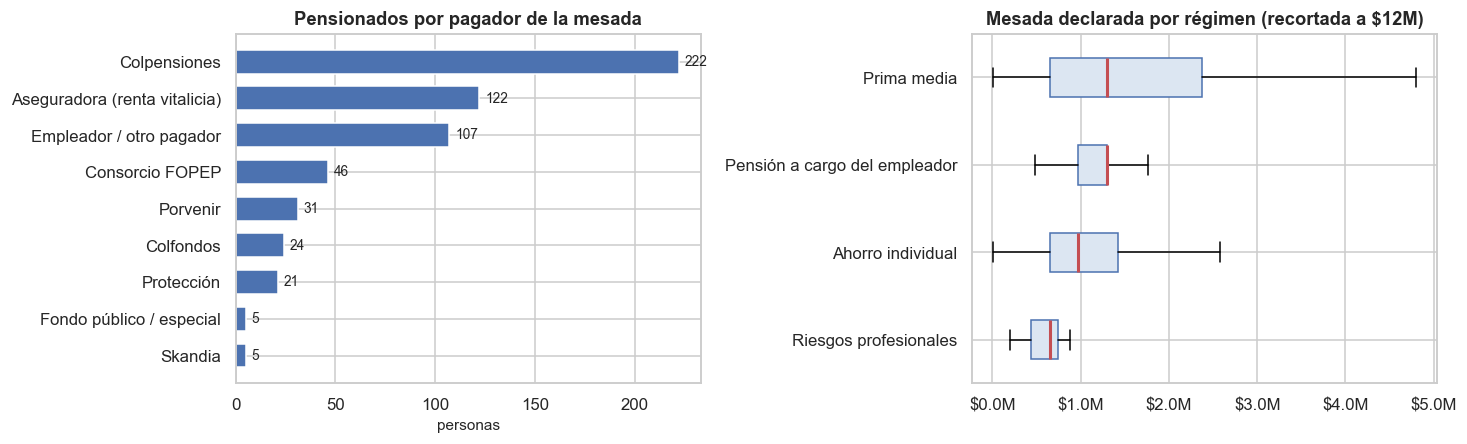

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
vc = perfil_pension["pagador_mesada"].value_counts().sort_values()
axes[0].barh(vc.index, vc.values, color=AZUL, height=0.65)
axes[0].set_title("Pensionados por pagador de la mesada")
axes[0].set_xlabel("personas")
for i, v in enumerate(vc.values):
    axes[0].text(v + 3, i, f"{v:,}", va="center", fontsize=9)

m = perfil_pension[perfil_pension["mesada_declarada"] > 0]
orden = m.groupby("regimen_pension")["mesada_declarada"].median().sort_values().index
axes[1].boxplot([m.loc[m["regimen_pension"] == r, "mesada_declarada"].clip(upper=12e6) for r in orden],
                tick_labels=[r.split(" (")[0] for r in orden], vert=False, showfliers=False,
                patch_artist=True, boxprops={"facecolor": "#dce6f2", "edgecolor": AZUL},
                medianprops={"color": ROJO, "linewidth": 2})
axes[1].set_title("Mesada declarada por régimen (recortada a $12M)")
axes[1].xaxis.set_major_formatter(cop)
plt.tight_layout(); plt.show()

### 2.2 · Cobertura transaccional: ¿a cuántos pensionados les vemos el consumo?

**Objetivo técnico.** Un pensionado solo es segmentable *por consumo* si ACH observa su gasto. Se cruza la
población identificada con PSE (pagos digitales) y Transferencias, y se fija el universo de modelado.

**Nota metodológica — una vía que se probó y se descarta.** Se exploró identificar pensionados por la vía
puramente transaccional: buscar la mesada como transferencia ACH recibida de un pagador de pensiones
(`Nombre usuario originador`). **No funciona con estos extractos**: los originadores visibles no incluyen a
Colpensiones ni a Porvenir (la mesada suele abonarse dentro del mismo banco, sin pasar por la cámara de
compensación), y los pocos originadores financieros que sí aparecen son fondos de cesantías y fiduciarias.
Se deja documentado porque acota qué se puede prometer con "solo ACH": **la certificación de pensionado
viene de PILA, el consumo viene de PSE**.

,personas,% de los identificados
Identificados en PILA,583,100.00
· con pagos digitales (PSE),392,67.20
· con transferencias (ACH/Transfiya),331,56.80
· con ambas fuentes,313,53.70
· sin ninguna huella transaccional,173,29.70


Con >= 2 meses de consumo PSE                  : 369
· excluidos por no tener mesada observable     : 9
UNIVERSO DE MODELADO                           : 360 pensionados


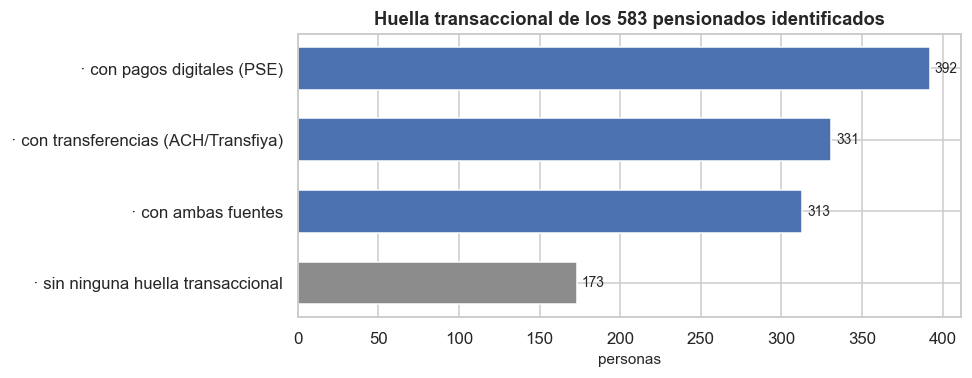

In [5]:
pse_pm = ap.build_person_month("pse", solo_ventana_comun=True)
trf_pm = ap.build_person_month("trf", solo_ventana_comun=True)
en_pse, en_trf = set(pse_pm["person_id"]), set(trf_pm["person_id"])

cobertura = pd.Series({
    "Identificados en PILA": len(pensionados),
    "· con pagos digitales (PSE)": len(pensionados & en_pse),
    "· con transferencias (ACH/Transfiya)": len(pensionados & en_trf),
    "· con ambas fuentes": len(pensionados & en_pse & en_trf),
    "· sin ninguna huella transaccional": len(pensionados - en_pse - en_trf),
})
display(cobertura.to_frame("personas").assign(
    **{"% de los identificados": (cobertura / len(pensionados) * 100).round(1)}))

# Universo de modelado: dos condiciones, ambas necesarias para que el modelo tenga sentido
#   1) consumo observable y estable  -> >= 2 meses con pagos PSE en la ventana
#   2) mesada observable             -> sin ella no se puede calcular la tasa de consumo
con_consumo = set(pse_pm[pse_pm["person_id"].isin(pensionados)]
                  .groupby("person_id")["periodo"].nunique().pipe(lambda s: s[s >= 2]).index)
con_mesada = set(perfil_pension.index[perfil_pension["mesada_declarada"] > 0])
universo = con_consumo & con_mesada
print(f"Con >= 2 meses de consumo PSE                  : {len(con_consumo):,}")
print(f"· excluidos por no tener mesada observable     : {len(con_consumo - con_mesada):,}")
print(f"UNIVERSO DE MODELADO                           : {len(universo):,} pensionados")

fig, ax = plt.subplots(figsize=(9, 3.6))
c = cobertura.drop("Identificados en PILA").sort_values()
ax.barh(c.index, c.values, color=[GRIS if "sin ninguna" in i else AZUL for i in c.index], height=0.6)
ax.set_title(f"Huella transaccional de los {len(pensionados):,} pensionados identificados")
ax.set_xlabel("personas")
for i, v in enumerate(c.values):
    ax.text(v + 3, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

## 3 · Decodificación de las entidades objetivo (Banca / Retail)

**Objetivo técnico.** Los nombres de comercio llegan ofuscados. Verificando el patrón sobre los 3.475
comercios distintos se comprueba que la ofuscación **sustituye los últimos 8 caracteres** por asteriscos:
el nombre visible es `nombre_real[:-8]` y, por tanto, **la longitud real del nombre es recuperable**
(`len(visible) + 8`). Eso permite un decodificador de dos condiciones —*prefijo compatible* **y**
*longitud exacta*— que resuelve casos que el prefijo solo dejaría ambiguos:

- `CAJA DE COMPENSACION FAMILIAR C********` → 31 + 8 = 39 = `CAJA DE COMPENSACION FAMILIAR COMPENSAR` → **Compensar**
- `CAJA DE COMPENSACIÓN FAMILI********` → 27 + 8 = 35 = `CAJA DE COMPENSACIÓN FAMILIAR CAFAM` → **Cafam**

Sin la longitud, ambos serían "una caja de compensación cualquiera". Se marca `alta` confianza cuando
prefijo **y** longitud coinciden, y `media` cuando solo coincide un prefijo largo e inequívoco.

**Interpretación de negocio.** Es la que convierte el dato ofuscado en una lista de clientes potenciales
concreta: sin este paso no se puede decir "el 21% de los pensionados le paga a Colsubsidio".

In [6]:
CANONICOS_OBJETIVO = {
    "Grupo Éxito":       ["ALMACENES EXITO", "EXITO VIAJES"],
    "Cencosud Colombia": ["CENCOSUD", "JUMBO", "TIENDAS METRO"],
    "Colsubsidio":       ["CAJA COLOMBIANA DE SUBSIDIO FAMILIAR COLSUBSIDIO"],
    "Compensar":         ["CAJA DE COMPENSACION FAMILIAR COMPENSAR"],
    "Cafam":             ["CAJA DE COMPENSACIÓN FAMILIAR CAFAM", "CAJA DE COMPENSACION FAMILIAR CAFAM"],
    "Bancolombia":       ["BANCOLOMBIA"],
    "Davivienda":        ["BANCO DAVIVIENDA"],
    "Colpensiones":      ["ADMINISTRADORA COLOMBIANA DE PENSIONES COLPENSIONES"],
    "Porvenir":          ["PORVENIR"],
}
GRUPO_OBJETIVO = {   # a qué frente comercial pertenece cada entidad
    "Grupo Éxito": "Retail", "Cencosud Colombia": "Retail",
    "Colsubsidio": "Caja de compensación", "Compensar": "Caja de compensación",
    "Cafam": "Caja de compensación",
    "Bancolombia": "Banca", "Davivienda": "Banca",
    "Colpensiones": "Pensiones", "Porvenir": "Pensiones",
}
N_MASCARA = 8   # la ofuscación reemplaza los últimos 8 caracteres


def _sin_tildes(s: str) -> str:
    return "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")


def decodificar_objetivo(valor: str) -> tuple[str, str]:
    """(entidad objetivo, confianza) para un nombre de comercio ofuscado."""
    s = str(valor).upper().strip()
    visible = s.rstrip("*").strip()
    if not visible:
        return ("No objetivo", "nula")
    largo_real = len(s.rstrip("*")) + N_MASCARA if s.endswith("*") else len(s)
    v = _sin_tildes(visible)
    for entidad, canonicos in CANONICOS_OBJETIVO.items():
        for canon in canonicos:
            c = _sin_tildes(canon.upper())
            if not c.startswith(v[:len(c)]) and not v.startswith(c[:len(v)]):
                continue
            if c.startswith(v) and len(c) == largo_real:      # prefijo + longitud exacta
                return (entidad, "alta")
            if v.startswith(c) or (c.startswith(v) and len(v) >= 10):
                return (entidad, "media")
    return ("No objetivo", "nula")


pse_raw = ap.add_person_key(ap.load_raw("pse").drop_duplicates(), "pse")
pse_raw["periodo"] = pse_raw["Periodo"].astype("string").str.slice(0, 7)
pse_raw = pse_raw[pse_raw["periodo"].between(*VENTANA).fillna(False).to_numpy(dtype=bool)].copy()
pse_raw["valor"] = ap.num(pse_raw["Valor"])
pse_raw["cantidad"] = ap.num(pse_raw["Cantidad"])
pse_raw["categoria"] = ap.categorize_comercio(pse_raw["Comercio"])

mapa_obj = {c: decodificar_objetivo(c) for c in pse_raw["Comercio"].dropna().astype("string").unique()}
pse_raw["entidad_objetivo"] = pse_raw["Comercio"].map(lambda c: mapa_obj.get(c, ("No objetivo", "nula"))[0])
pse_raw["objetivo_confianza"] = pse_raw["Comercio"].map(lambda c: mapa_obj.get(c, ("No objetivo", "nula"))[1])

hit = pse_raw[pse_raw["entidad_objetivo"] != "No objetivo"]
tabla_obj = (hit.groupby("entidad_objetivo")
             .agg(comercios=("Comercio", "nunique"), pagos=("valor", "size"),
                  personas=("person_id", "nunique"), valor_total=("valor", "sum"),
                  confianza=("objetivo_confianza", lambda s: s.mode().iat[0]))
             .reindex(CANONICOS_OBJETIVO.keys()))
tabla_obj["grupo"] = [GRUPO_OBJETIVO[e] for e in tabla_obj.index]
tabla_obj["pensionados"] = (hit[hit["person_id"].isin(universo)]
                            .groupby("entidad_objetivo")["person_id"].nunique()
                            .reindex(tabla_obj.index))
tabla_obj["confianza"] = tabla_obj["confianza"].fillna("sin presencia")
for c in ["comercios", "pagos", "personas", "pensionados", "valor_total"]:
    tabla_obj[c] = tabla_obj[c].fillna(0).astype("int64")
display(tabla_obj[["grupo", "confianza", "comercios", "pagos", "personas", "pensionados",
                   "valor_total"]])
print("Entidades objetivo sin presencia en PSE:",
      ", ".join(sorted(set(CANONICOS_OBJETIVO) - set(hit["entidad_objetivo"]))) or "ninguna")

,grupo,confianza,comercios,pagos,personas,pensionados,valor_total
entidad_objetivo,,,,,,,
Grupo Éxito,Retail,media,3,1286,554,14,202416044
Cencosud Colombia,Retail,sin presencia,0,0,0,0,0
Colsubsidio,Caja de compensación,alta,1,5684,1789,15,1283600015
Compensar,Caja de compensación,alta,3,3949,1201,15,1187715742
Cafam,Caja de compensación,sin presencia,0,0,0,0,0
Bancolombia,Banca,sin presencia,0,0,0,0,0
Davivienda,Banca,media,2,24575,5171,77,20520494599
Colpensiones,Pensiones,alta,1,190,44,0,16813976
Porvenir,Pensiones,sin presencia,0,0,0,0,0


Entidades objetivo sin presencia en PSE: Bancolombia, Cafam, Cencosud Colombia, Porvenir


**Lectura.** Las cajas de compensación (**Colsubsidio**, **Compensar**, **Cafam**) y la banca
(**Bancolombia**, **Davivienda**) recaudan por PSE de forma masiva; **Grupo Éxito** aparece con volumen
menor —el retail físico no se paga por PSE— y **Cencosud Colombia** no aparece en absoluto en el extracto.
Es un hallazgo, no un error: PSE ve el **recaudo en línea**, no la compra en tienda. Para un retailer, la
conclusión operativa es que su relación con el pensionado hoy es invisible para este canal, y que la
palanca disponible es la **alianza con quien sí lo ve** (caja de compensación o banco).

## 4 · Ingeniería de características de consumo

**Objetivo técnico.** Construir una tabla **una fila = un pensionado** con la señal de consumo de los 18
meses de la ventana común, en cinco bloques:

| Bloque | Variables | Qué captura |
|---|---|---|
| **RFM** | `recencia_meses`, `n_pagos`, `gasto_total`, `gasto_mensual_medio` | intensidad y vigencia de la relación |
| **Hábito** | `regularidad`, `volatilidad_gasto`, `hhi_mensual`, `ticket_medio`, `n_comercios` | si el gasto es rítmico (patrón de mesada) o esporádico |
| **Composición** | `share_deuda`, `share_servicios`, `share_salud`, `share_retail`, `share_ocio`, `share_obligaciones`, `diversificacion` | en qué se va la mesada |
| **Capacidad** | `mesada_declarada`, `tasa_consumo`, `meses_gasto_sobre_mesada`, `ingreso_ach_mensual` | cuánto de la mesada se observa gastado |
| **Comercial** | `share_entidades_objetivo`, `usa_caja_compensacion`, `usa_retail_objetivo`, `usa_banca_objetivo` | relación con las empresas objetivo |

**Interpretación de negocio.** El pensionado no se distingue por *cuánto* gana —su mesada está acotada por
ley— sino por **cómo la administra**: quién la destina a servicio de deuda, quién a salud, quién la gasta
de forma rítmica y quién a golpes. Esa es la variable comercial, y es la que este bloque hace explícita.

**Sobre las categorías.** Se agrupan las 13 categorías de la taxonomía de comercios de `ach_pipeline` en 6
bloques de negocio legibles para un comité; `Pasarelas / agregadores` y `Otros / no clasificado` se
mantienen aparte como **gasto intermediado** (no se sabe qué hay detrás) y **no** se usan como feature de
modelado, para no clusterizar por un artefacto de la ofuscación.

In [7]:
BLOQUES_GASTO = {
    "deuda":         ["Financiero / créditos"],
    "servicios":     ["Telco / servicios públicos"],
    "salud":         ["Salud", "Seguros"],
    "retail":        ["Comercio electrónico / retail"],
    "ocio":          ["Viajes / transporte", "Streaming / digital", "Apuestas y juegos"],
    "obligaciones":  ["Gobierno / impuestos", "Educación", "Seguridad social / nómina"],
    "intermediado":  ["Pasarelas / agregadores", "Otros / no clasificado"],
}
MAPA_BLOQUE = {cat: bloque for bloque, cats in BLOQUES_GASTO.items() for cat in cats}
assert set(MAPA_BLOQUE) >= set(ap.CATEGORIAS_COMERCIO), "Hay categorías sin bloque asignado"

pse_pens = pse_raw[pse_raw["person_id"].isin(universo)].copy()
pse_pens["bloque"] = pse_pens["categoria"].map(MAPA_BLOQUE).fillna("intermediado")

# --- Panel persona × mes (base de las métricas de ritmo) -------------------- #
panel = pse_pens.groupby(["person_id", "periodo"], as_index=False).agg(
    gasto=("valor", "sum"), pagos=("cantidad", "sum"))
gp = panel.groupby("person_id")

# --- Bloque RFM + hábito ---------------------------------------------------- #
g = pse_pens.groupby("person_id")
F = pd.DataFrame({
    "gasto_total": g["valor"].sum(),
    "n_pagos": g["cantidad"].sum(),
    "n_comercios": g["Comercio"].nunique(),
    "meses_activos": gp["periodo"].nunique(),
    "gasto_mensual_medio": gp["gasto"].mean(),
    "gasto_mensual_max": gp["gasto"].max(),
    "ultimo_periodo": gp["periodo"].max(),
})
_desfase = pd.Period(VENTANA[1], freq="M") - pd.PeriodIndex(F["ultimo_periodo"], freq="M")
F["recencia_meses"] = pd.Series([d.n for d in _desfase], index=F.index).clip(lower=0)
F["regularidad"] = F["meses_activos"] / N_MESES
F["ticket_medio"] = F["gasto_total"] / F["n_pagos"].replace(0, np.nan)
F["volatilidad_gasto"] = (gp["gasto"].std() / gp["gasto"].mean()).fillna(0.0)
# HHI mensual: 1/meses_activos = gasto perfectamente repartido; 1 = todo en un mes
share_mes = panel["gasto"] / panel.groupby("person_id")["gasto"].transform("sum").replace(0, np.nan)
F["hhi_mensual"] = (share_mes.pow(2).groupby(panel["person_id"]).sum()).fillna(1.0)

# --- Bloque composición del gasto ------------------------------------------- #
piv = (pse_pens.pivot_table(index="person_id", columns="bloque", values="valor",
                            aggfunc="sum", fill_value=0.0)
       .reindex(columns=list(BLOQUES_GASTO), fill_value=0.0))
shares = piv.div(piv.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
F = F.join(shares.add_prefix("share_"))
# Entropía de Shannon normalizada sobre los 7 bloques: 0 = todo el gasto en un bloque, 1 = repartido.
# Se calcula sobre los 7 (incluido el intermediado) para no inventar una diversificación que no se ve.
F["diversificacion"] = (-(shares * np.log(shares.replace(0, np.nan))).sum(axis=1)
                        / np.log(shares.shape[1])).fillna(0.0)
# Dos agregados de negocio menos dispersos que los bloques sueltos (la mayoría de personas
# tiene 0 en salud, retail u ocio por separado; sumados sí discriminan)
F["share_esencial"] = F[["share_servicios", "share_salud", "share_obligaciones"]].sum(axis=1)
F["share_discrecional"] = F[["share_retail", "share_ocio"]].sum(axis=1)

# --- Bloque capacidad: mesada declarada y presión sobre ella ---------------- #
F = F.join(perfil_pension[["mesada_declarada", "pagador_mesada", "regimen_pension",
                           "meses_como_pensionado"]])
F["tasa_consumo"] = (F["gasto_mensual_medio"] / F["mesada_declarada"]).clip(upper=5.0)
F["en_riesgo_desconexion"] = F["recencia_meses"] >= 3   # bandera de negocio, no dimensión del cluster
mesada_por_persona = F["mesada_declarada"].reindex(panel["person_id"]).to_numpy()
F["meses_gasto_sobre_mesada"] = (panel.assign(sobre=panel["gasto"].to_numpy() > mesada_por_persona)
                                 .query("sobre").groupby("person_id").size()).reindex(F.index).fillna(0)

# --- Bloque flujos ACH (enriquecimiento, no define el cluster) -------------- #
t = trf_pm[trf_pm["person_id"].isin(universo)].groupby("person_id").agg(
    recibido=("recibido", "sum"), enviado=("enviado", "sum"),
    n_recibidas=("n_recibidas", "sum"), recibido_transfiya=("recibido_transfiya", "sum"))
F = F.join(t)
F[["recibido", "enviado", "n_recibidas", "recibido_transfiya"]] = \
    F[["recibido", "enviado", "n_recibidas", "recibido_transfiya"]].fillna(0.0)
F["ingreso_ach_mensual"] = F["recibido"] / N_MESES
F["transfiya_share"] = (F["recibido_transfiya"] / F["recibido"].replace(0, np.nan)).fillna(0.0)

# --- Bloque comercial: entidades objetivo ----------------------------------- #
obj = pse_pens[pse_pens["entidad_objetivo"] != "No objetivo"]
F["gasto_entidades_objetivo"] = obj.groupby("person_id")["valor"].sum().reindex(F.index).fillna(0.0)
F["share_entidades_objetivo"] = (F["gasto_entidades_objetivo"]
                                 / F["gasto_total"].replace(0, np.nan)).fillna(0.0)
F["n_entidades_objetivo"] = obj.groupby("person_id")["entidad_objetivo"].nunique().reindex(F.index).fillna(0)
for grupo, etiqueta in [("Caja de compensación", "usa_caja_compensacion"),
                        ("Retail", "usa_retail_objetivo"), ("Banca", "usa_banca_objetivo")]:
    ids = set(obj.loc[obj["entidad_objetivo"].map(GRUPO_OBJETIVO) == grupo, "person_id"])
    F[etiqueta] = F.index.isin(ids)

F = F.reset_index().rename(columns={"index": "person_id"})
print(f"Tabla analítica de pensionados: {F.shape[0]:,} personas × {F.shape[1]} variables")
display(F[["gasto_total", "gasto_mensual_medio", "n_pagos", "n_comercios", "ticket_medio",
           "meses_activos", "regularidad", "recencia_meses", "volatilidad_gasto",
           "mesada_declarada", "tasa_consumo", "diversificacion"]]
        .describe(percentiles=[.25, .5, .75, .95]).T.round(2))

Tabla analítica de pensionados: 360 personas × 42 variables


,count,mean,std,min,25%,50%,75%,95%,max
gasto_total,360.00,"19,812,256.48","36,469,977.75","37,019.00","2,516,968.23","7,663,392.34","20,123,184.36","81,999,717.14","358,353,406.38"
gasto_mensual_medio,360.00,"1,213,815.69","2,015,598.32","14,247.50","260,771.80","552,165.20","1,235,617.65","4,582,417.20","19,908,522.58"
n_pagos,360.00,79.63,102.90,2.00,20.75,49.00,103.00,247.45,"1,121.00"
n_comercios,360.00,13.39,9.25,1.00,6.00,12.00,18.00,32.00,42.00
ticket_medio,360.00,"233,237.87","240,671.77","9,254.75","92,489.18","166,166.42","260,527.48","666,030.82","1,921,113.57"
meses_activos,360.00,13.39,5.18,2.00,9.00,16.00,18.00,18.00,18.00
regularidad,360.00,0.74,0.29,0.11,0.50,0.89,1.00,1.00,1.00
recencia_meses,360.00,1.08,2.84,0.00,0.00,0.00,0.00,7.00,16.00
volatilidad_gasto,360.00,0.91,0.41,0.00,0.63,0.84,1.13,1.65,2.59
mesada_declarada,360.00,"1,563,301.14","2,676,809.44","38,700.00","650,000.00","1,160,000.00","1,398,375.00","3,763,903.10","29,072,210.50"


### 4.1 · Distribuciones: cómo se ve el consumo del pensionado

**Objetivo técnico.** Verificar el sesgo de las variables monetarias (justifica la transformación
logarítmica) y la forma de las variables de hábito antes de escalar.

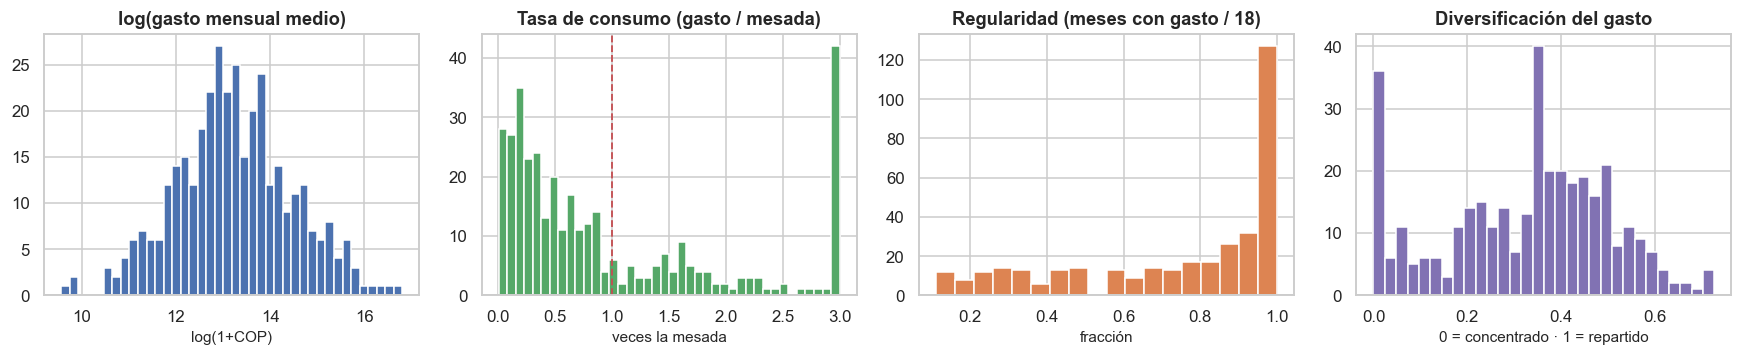

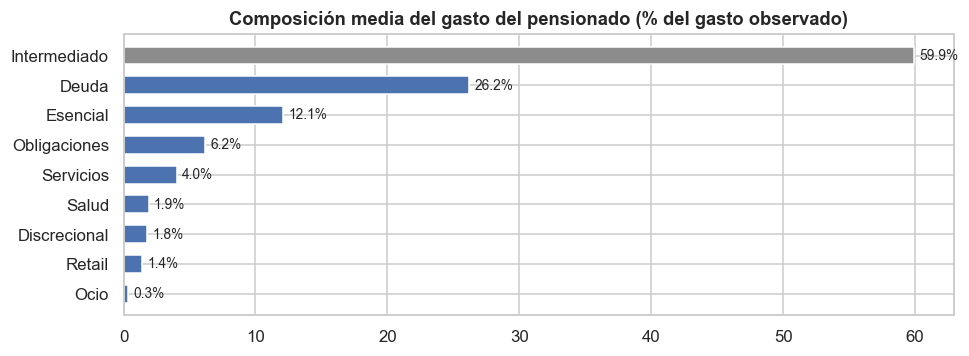

En gris, el gasto INTERMEDIADO (pasarelas y comercios no clasificables): es el techo de lo que
esta fuente puede explicar sin un catálogo maestro de comercios.


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
axes[0].hist(np.log1p(F["gasto_mensual_medio"]), bins=40, color=AZUL, edgecolor="white")
axes[0].set_title("log(gasto mensual medio)"); axes[0].set_xlabel("log(1+COP)")
axes[1].hist(F["tasa_consumo"].clip(upper=3), bins=40, color=VERDE, edgecolor="white")
axes[1].axvline(1, color=ROJO, ls="--", lw=1.2)
axes[1].set_title("Tasa de consumo (gasto / mesada)"); axes[1].set_xlabel("veces la mesada")
axes[2].hist(F["regularidad"], bins=18, color=NARANJA, edgecolor="white")
axes[2].set_title("Regularidad (meses con gasto / 18)"); axes[2].set_xlabel("fracción")
axes[3].hist(F["diversificacion"], bins=30, color=MORADO, edgecolor="white")
axes[3].set_title("Diversificación del gasto"); axes[3].set_xlabel("0 = concentrado · 1 = repartido")
plt.tight_layout(); plt.show()

comp = F[[c for c in F.columns if c.startswith("share_") and c != "share_entidades_objetivo"]].mean() * 100
fig, ax = plt.subplots(figsize=(9, 3.4))
comp = comp.sort_values()
colores = [GRIS if "intermediado" in i else AZUL for i in comp.index]
ax.barh([i.replace("share_", "").capitalize() for i in comp.index], comp.values, color=colores, height=0.6)
ax.set_title("Composición media del gasto del pensionado (% del gasto observado)")
for i, v in enumerate(comp.values):
    ax.text(v + 0.4, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout(); plt.show()
print("En gris, el gasto INTERMEDIADO (pasarelas y comercios no clasificables): es el techo de lo que")
print("esta fuente puede explicar sin un catálogo maestro de comercios.")

### 4.2 · Ritmo del gasto frente a la mesada

**Objetivo técnico y limitación.** El caso de uso pide analizar el **comportamiento cerca de la fecha de
pago de la pensión**. Los tres extractos son **mensuales** (`Periodo` = `YYYY-MM`, sin día), así que el
efecto intra-mes **no es observable** y no se va a simular. Se sustituye por dos proxies mensuales que sí
son medibles y responden a la misma pregunta de negocio ("¿el consumo sigue el pulso de la mesada?"):

- **`regularidad`** — en cuántos de los 18 meses hubo gasto. Alta = consumo rítmico, atado al ingreso mensual.
- **`hhi_mensual`** — concentración del gasto entre meses. Alta = gasto a golpes (compras puntuales,
  emergencias), típico de quien no usa el canal digital como rutina.

**Interpretación de negocio.** Un pensionado con alta regularidad y baja concentración es un cliente de
**débito automático y suscripción**; uno con gasto concentrado responde mejor a **campañas por evento**
(prima de mitad y fin de año, temporadas de salud).

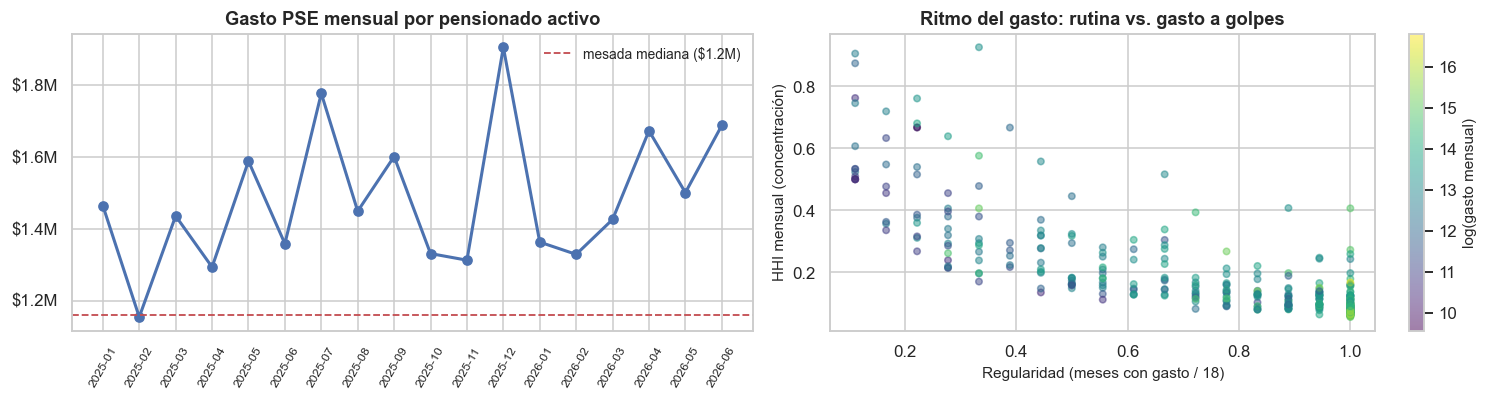

Meses en que el gasto observado supera la mesada — mediana por persona: 2 de 18


In [9]:
serie = (pse_pens.groupby("periodo")
         .agg(gasto=("valor", "sum"), personas=("person_id", "nunique")).reset_index())
serie["gasto_por_persona"] = serie["gasto"] / serie["personas"]
mesada_mediana = F.loc[F["mesada_declarada"] > 0, "mesada_declarada"].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
axes[0].plot(serie["periodo"], serie["gasto_por_persona"], "o-", color=AZUL, lw=2)
axes[0].axhline(mesada_mediana, color=ROJO, ls="--", lw=1.2,
                label=f"mesada mediana (${mesada_mediana/1e6:,.1f}M)")
axes[0].set_title("Gasto PSE mensual por pensionado activo")
axes[0].yaxis.set_major_formatter(cop); axes[0].legend(fontsize=9)
axes[0].tick_params(axis="x", rotation=60, labelsize=8)
sc = axes[1].scatter(F["regularidad"], F["hhi_mensual"], s=18, alpha=.5,
                     c=np.log1p(F["gasto_mensual_medio"]), cmap="viridis")
axes[1].set_xlabel("Regularidad (meses con gasto / 18)"); axes[1].set_ylabel("HHI mensual (concentración)")
axes[1].set_title("Ritmo del gasto: rutina vs. gasto a golpes")
plt.colorbar(sc, ax=axes[1], label="log(gasto mensual)")
plt.tight_layout(); plt.show()
print(f"Meses en que el gasto observado supera la mesada — mediana por persona: "
      f"{F['meses_gasto_sobre_mesada'].median():.0f} de {N_MESES}")

## 5 · Preprocesamiento

**Objetivo técnico.** Dejar la matriz lista para una métrica de distancia euclidiana.

**Selección de variables — y por qué no entran todas.** No toda variable calculada sirve para clusterizar.
Se revisó la dispersión de cada una y se dejaron fuera del modelo (conservándolas para el perfilamiento):

| Descartada | Motivo |
|---|---|
| `share_salud`, `share_retail`, `share_ocio` | 77%, 66% y 93% de ceros: separan outliers, no poblaciones. Entran sumadas en `share_esencial` y `share_discrecional` |
| `recencia_meses` | 76% de ceros (casi todos activos el último mes): aporta ruido como dimensión. Se usa como **bandera** de negocio (`en_riesgo_desconexion`) |
| `n_pagos` | ρ = 0,88 con `regularidad` y 0,83 con `n_comercios`: señal duplicada |
| `mesada_declarada` | es capacidad, no consumo; ya entra en términos relativos dentro de `tasa_consumo` |

Quedan **8 variables** que sí describen *cómo consume* el pensionado: intensidad (`gasto_mensual_medio`,
`ticket_medio`, `n_comercios`), hábito (`regularidad`, `diversificacion`), composición (`share_deuda`,
`share_esencial`) y presión sobre el ingreso (`tasa_consumo`).

**Resto del preprocesamiento.**
1. **Nulos**: no quedan; las variables que podían faltar (mesada) definen el universo, no se imputan.
2. **Outliers**: *winsorización* al percentil 1–99. No se eliminan personas — en una población de cientos,
   descartar la cola es descartar justamente al pensionado de consumo alto, que es un segmento comercial.
3. **Escala**: `log1p` en montos y conteos (sesgo a la derecha) y comparación empírica
   **StandardScaler vs RobustScaler**.
4. **PCA** solo para diagnóstico y visualización: con 8 variables no hay maldición de dimensionalidad y el
   clustering se hace sobre el espacio completo.

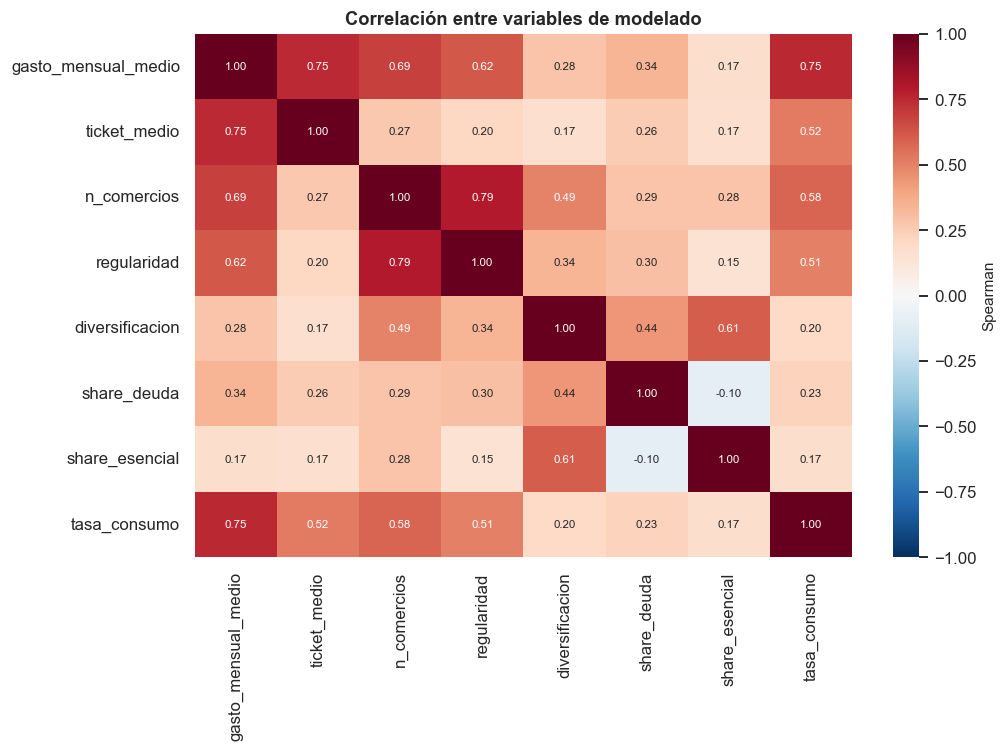

Pares con |rho| >= 0,80: ninguno -> no hay redundancia que forzar a eliminar


In [10]:
FEATURES = [
    "gasto_mensual_medio", "ticket_medio", "n_comercios",   # intensidad del consumo
    "regularidad", "diversificacion",                        # hábito
    "share_deuda", "share_esencial",                         # composición del gasto
    "tasa_consumo",                                          # presión sobre la mesada
]
LOG_FEATURES = ["gasto_mensual_medio", "ticket_medio", "n_comercios"]

corr = F[FEATURES].corr(method="spearman")
fig, ax = plt.subplots(figsize=(9.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot_kws={"size": 7.5}, cbar_kws={"label": "Spearman"}, ax=ax)
ax.set_title("Correlación entre variables de modelado")
plt.tight_layout(); plt.show()
altas = [(a, b, corr.loc[a, b]) for i, a in enumerate(FEATURES) for b in FEATURES[i + 1:]
         if abs(corr.loc[a, b]) >= 0.8]
print("Pares con |rho| >= 0,80:", altas if altas else "ninguno -> no hay redundancia que forzar a eliminar")

In [11]:
X = F[FEATURES].copy().astype(float)

# 1) Winsorización p1-p99 (se recuerdan los límites: hacen parte del artefacto del modelo)
LIMITES = {c: (X[c].quantile(0.01), X[c].quantile(0.99)) for c in FEATURES}
recortados = int(sum(((X[c] < lo) | (X[c] > hi)).sum() for c, (lo, hi) in LIMITES.items()))
for c, (lo, hi) in LIMITES.items():
    X[c] = X[c].clip(lo, hi)

# 2) Log en montos y conteos
for c in LOG_FEATURES:
    X[c] = np.log1p(X[c])

print(f"Nulos tras el ensamble : {int(X.isna().sum().sum())}")
print(f"Valores winsorizados   : {recortados:,} de {X.size:,} celdas "
      f"({recortados / X.size * 100:.1f}%)")

# 3) StandardScaler vs RobustScaler bajo el CRITERIO DE ACCIONABILIDAD (ver nota siguiente):
#    entre las soluciones donde ningún segmento baja del 5% ni supera el 50% de la base,
#    se elige la de mejor silueta. Una partición con el 80% de la gente en un grupo no es
#    una segmentación, aunque su silueta sea alta.
MIN_SEG, MAX_SEG = 0.05, 0.50
comparacion_escala = []
for nombre, escalador in [("StandardScaler", StandardScaler()), ("RobustScaler", RobustScaler())]:
    Z = escalador.fit_transform(X)
    for k in range(3, 8):
        etq = KMeans(n_clusters=k, n_init=30, random_state=SEMILLA).fit_predict(Z)
        tam = pd.Series(etq).value_counts(normalize=True)
        comparacion_escala.append({
            "escalador": nombre, "k": k,
            "silueta": silhouette_score(Z, etq),
            "davies_bouldin": davies_bouldin_score(Z, etq),
            "segmento_menor_%": tam.min() * 100, "segmento_mayor_%": tam.max() * 100,
            "equilibrada": bool(tam.min() >= MIN_SEG and tam.max() <= MAX_SEG)})
comparacion_escala = pd.DataFrame(comparacion_escala)
display(comparacion_escala.round(3))

viables = comparacion_escala[comparacion_escala["equilibrada"]]
ganadora = viables.loc[viables["silueta"].idxmax()]
ESCALADOR = StandardScaler() if ganadora["escalador"] == "StandardScaler" else RobustScaler()
K = int(ganadora["k"])
Xs = ESCALADOR.fit_transform(X)
print(f"Configuración elegida: {ganadora['escalador']} · k = {K} · "
      f"silueta = {ganadora['silueta']:.3f} · segmentos entre "
      f"{ganadora['segmento_menor_%']:.0f}% y {ganadora['segmento_mayor_%']:.0f}% de la base")
print(f"Matriz de modelado: {Xs.shape}")

Nulos tras el ensamble : 0
Valores winsorizados   : 36 de 2,880 celdas (1.2%)


,escalador,k,silueta,davies_bouldin,segmento_menor_%,segmento_mayor_%,equilibrada
0,StandardScaler,3,0.22,1.51,18.61,51.67,False
1,StandardScaler,4,0.25,1.31,9.44,48.61,True
2,StandardScaler,5,0.24,1.27,9.44,40.83,True
3,StandardScaler,6,0.23,1.30,8.89,31.39,True
4,StandardScaler,7,0.22,1.29,8.33,20.56,True
5,RobustScaler,3,0.27,1.25,18.33,51.39,False
6,RobustScaler,4,0.27,1.20,10.28,47.78,True
7,RobustScaler,5,0.26,1.22,5.00,41.11,True
8,RobustScaler,6,0.21,1.41,5.00,31.39,True
9,RobustScaler,7,0.22,1.35,5.00,19.72,True


Configuración elegida: RobustScaler · k = 4 · silueta = 0.271 · segmentos entre 10% y 48% de la base
Matriz de modelado: (360, 8)


> **Nota metodológica — por qué la silueta no decide sola.** Con las 13 variables iniciales, el
> `RobustScaler` alcanzaba una silueta de **0,62**… aislando tres grupos de 20-35 personas y dejando al
> **79% de la base en un único cluster**. Es el artefacto clásico de escalar por rango intercuartílico
> variables con muchos ceros (`share_salud` tiene 77% de ceros → su IQR es casi nulo → al dividir por él,
> unos pocos outliers dominan toda la distancia). La silueta premia esa partición porque cuatro puntos muy
> lejanos están muy bien separados; el negocio no recibe nada. Por eso la selección exige, además de buena
> silueta, que **ningún segmento baje del 5% ni supere el 50%** de la base.

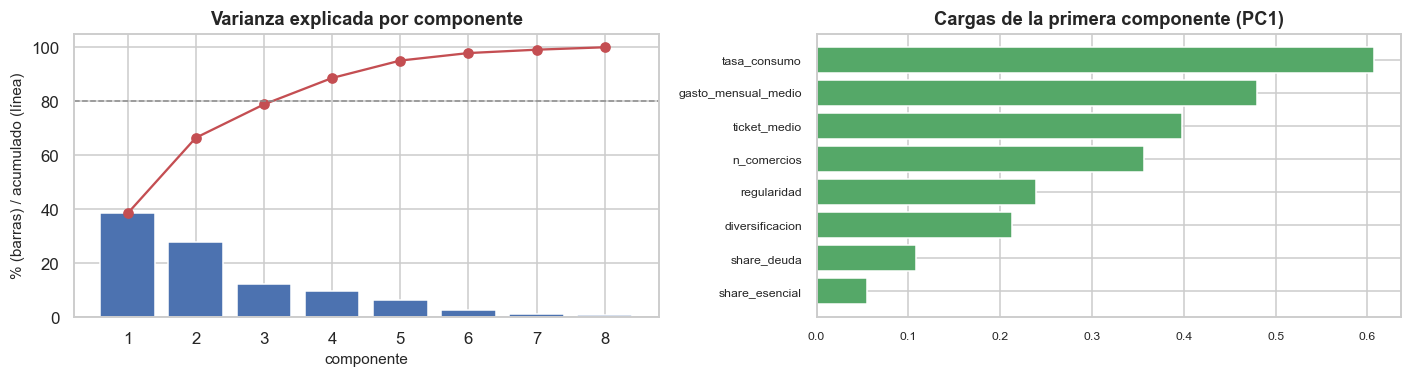

Componentes para explicar el 80% de la varianza: 4 de 8


In [12]:
pca_diag = PCA(random_state=SEMILLA).fit(Xs)
var = np.cumsum(pca_diag.explained_variance_ratio_)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].bar(range(1, len(var) + 1), pca_diag.explained_variance_ratio_ * 100, color=AZUL)
axes[0].plot(range(1, len(var) + 1), var * 100, "o-", color=ROJO, lw=1.5)
axes[0].axhline(80, color=GRIS, ls="--", lw=1)
axes[0].set_title("Varianza explicada por componente"); axes[0].set_xlabel("componente")
axes[0].set_ylabel("% (barras) / acumulado (línea)")
cargas = pd.DataFrame(pca_diag.components_[:2].T, index=FEATURES, columns=["PC1", "PC2"])
orden_c = cargas["PC1"].abs().sort_values().index
axes[1].barh(orden_c, cargas.loc[orden_c, "PC1"], color=[VERDE if v > 0 else NARANJA
                                                         for v in cargas.loc[orden_c, "PC1"]])
axes[1].set_title("Cargas de la primera componente (PC1)")
axes[1].tick_params(labelsize=8)
plt.tight_layout(); plt.show()
print(f"Componentes para explicar el 80% de la varianza: {int(np.argmax(var >= 0.80) + 1)} de {len(var)}")

## 6 · Modelado: validación del número de segmentos y elección de algoritmo

**Objetivo técnico.** Confirmar el `k = K` que salió del barrido anterior mirando las tres curvas
clásicas —**codo** (inercia), **silueta** (mayor es mejor) y **Davies-Bouldin** (menor es mejor)— y luego
comparar tres familias de clustering sobre la misma matriz: **K-Means** (particional), **jerárquico Ward**
(aglomerativo) y **DBSCAN** (por densidad).

**Interpretación de negocio.** `k = 2` casi siempre gana en silueta y casi nunca sirve: parte la base en
"gasta / no gasta". La tabla incluye el tamaño del segmento mayor y menor para que la decisión sea
auditable: se ve qué `k` es técnicamente bueno **y** comercialmente utilizable.

,inercia,silueta,davies_bouldin,calinski_harabasz,segmento_menor_%,segmento_mayor_%,accionable
k,,,,,,,
2,"1,559.23",0.23,1.64,113.81,41.11,58.89,no
3,"1,165.61",0.27,1.25,136.19,18.33,51.39,no
4,920.79,0.27,1.20,146.16,10.28,47.78,sí
5,821.06,0.26,1.22,133.37,5.00,41.11,sí
6,748.45,0.21,1.41,123.59,5.00,31.39,sí
7,688.61,0.22,1.35,116.73,5.00,19.72,sí
8,638.80,0.22,1.24,111.48,5.00,16.39,sí


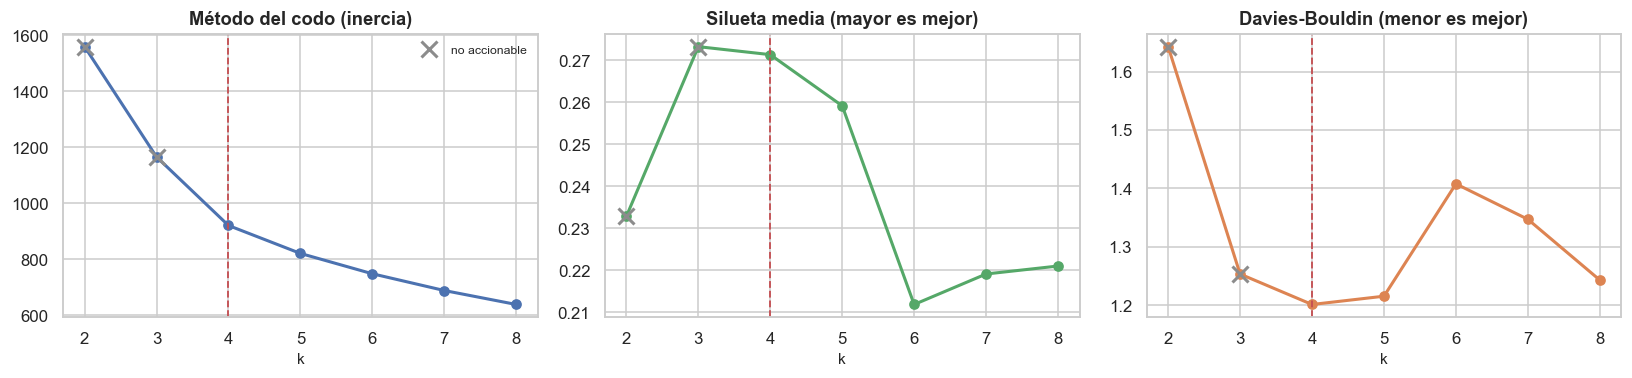

k = 4 · silueta = 0.271 · Davies-Bouldin = 1.201 · Calinski-Harabasz = 146
Segmentos entre 10% y 48% de la base


In [13]:
RANGO_K = range(2, 9)
metricas_k = []
for k in RANGO_K:
    km = KMeans(n_clusters=k, n_init=30, random_state=SEMILLA).fit(Xs)
    tam = pd.Series(km.labels_).value_counts(normalize=True)
    metricas_k.append({"k": k, "inercia": km.inertia_,
                       "silueta": silhouette_score(Xs, km.labels_),
                       "davies_bouldin": davies_bouldin_score(Xs, km.labels_),
                       "calinski_harabasz": calinski_harabasz_score(Xs, km.labels_),
                       "segmento_menor_%": tam.min() * 100, "segmento_mayor_%": tam.max() * 100})
metricas_k = pd.DataFrame(metricas_k).set_index("k")
metricas_k["accionable"] = np.where(
    (metricas_k["segmento_menor_%"] >= MIN_SEG * 100) & (metricas_k["segmento_mayor_%"] <= MAX_SEG * 100),
    "sí", "no")
display(metricas_k.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, (col, titulo, color) in zip(axes, [
        ("inercia", "Método del codo (inercia)", AZUL),
        ("silueta", "Silueta media (mayor es mejor)", VERDE),
        ("davies_bouldin", "Davies-Bouldin (menor es mejor)", NARANJA)]):
    ax.plot(metricas_k.index, metricas_k[col], "o-", color=color, lw=2)
    no_acc = metricas_k[metricas_k["accionable"] == "no"]
    ax.plot(no_acc.index, no_acc[col], "x", color=GRIS, ms=11, mew=2, label="no accionable")
    ax.axvline(K, color=ROJO, ls="--", lw=1.2)
    ax.set_title(titulo); ax.set_xlabel("k")
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"k = {K} · silueta = {metricas_k.loc[K, 'silueta']:.3f} · "
      f"Davies-Bouldin = {metricas_k.loc[K, 'davies_bouldin']:.3f} · "
      f"Calinski-Harabasz = {metricas_k.loc[K, 'calinski_harabasz']:,.0f}")
print(f"Segmentos entre {metricas_k.loc[K, 'segmento_menor_%']:.0f}% y "
      f"{metricas_k.loc[K, 'segmento_mayor_%']:.0f}% de la base")

### 6.1 · K-Means vs. jerárquico (Ward) vs. DBSCAN

**Objetivo técnico.** Comprobar que la estructura encontrada no es un artefacto del algoritmo. Para DBSCAN,
`eps` se fija con el método de la k-distancia (codo de la distancia al 5.º vecino más cercano), no a ojo.

,clusters,ruido_%,menor_%,mayor_%,silueta,davies_bouldin,accionable
K-Means (k=4),4,0.00,10.30,47.80,0.27,1.20,sí
Ward jerárquico (k=4),4,0.00,10.30,60.30,0.25,1.14,no
"DBSCAN (eps=1.50, min=5)",2,4.20,0.90,99.10,0.43,0.57,no


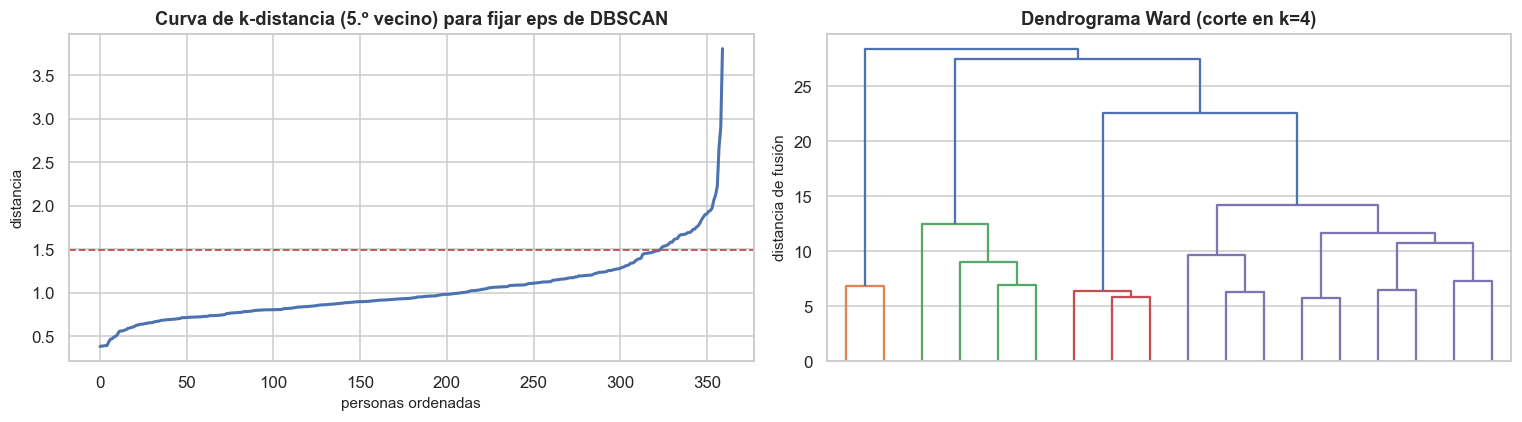

Concordancia K-Means vs. Ward · índice de Rand ajustado = 0.474 (1 = partición idéntica, 0 = coincidencia al azar)


Ward,0,1,2,3
K-Means,,,,
0,1,0,36,0
1,50,1,3,53
2,8,36,0,0
3,158,0,14,0


In [14]:
vecinos = NearestNeighbors(n_neighbors=5).fit(Xs)
dist_k = np.sort(vecinos.kneighbors(Xs)[0][:, -1])
EPS = float(np.quantile(dist_k, 0.90))   # codo empírico de la curva de k-distancia

modelo_kmeans = KMeans(n_clusters=K, n_init=50, random_state=SEMILLA).fit(Xs)
etiquetas_ward = AgglomerativeClustering(n_clusters=K, linkage="ward").fit_predict(Xs)
modelos = {
    f"K-Means (k={K})": modelo_kmeans.labels_,
    f"Ward jerárquico (k={K})": etiquetas_ward,
    f"DBSCAN (eps={EPS:.2f}, min=5)": DBSCAN(eps=EPS, min_samples=5).fit_predict(Xs),
}


def evaluar(etiquetas):
    validos = etiquetas != -1
    n_clusters = len(set(etiquetas[validos]))
    tam = pd.Series(etiquetas[validos]).value_counts(normalize=True)
    base = {"clusters": n_clusters, "ruido_%": round((~validos).mean() * 100, 1),
            "menor_%": round(tam.min() * 100, 1), "mayor_%": round(tam.max() * 100, 1)}
    if n_clusters < 2:
        return {**base, "silueta": np.nan, "davies_bouldin": np.nan, "accionable": "no"}
    return {**base,
            "silueta": silhouette_score(Xs[validos], etiquetas[validos]),
            "davies_bouldin": davies_bouldin_score(Xs[validos], etiquetas[validos]),
            "accionable": "sí" if (tam.min() >= MIN_SEG and tam.max() <= MAX_SEG) else "no"}


comparacion = pd.DataFrame({n: evaluar(e) for n, e in modelos.items()}).T
display(comparacion)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(dist_k, color=AZUL, lw=2); axes[0].axhline(EPS, color=ROJO, ls="--", lw=1.2)
axes[0].set_title("Curva de k-distancia (5.º vecino) para fijar eps de DBSCAN")
axes[0].set_xlabel("personas ordenadas"); axes[0].set_ylabel("distancia")
Z = linkage(Xs, method="ward")
dendrogram(Z, truncate_mode="lastp", p=18, ax=axes[1], color_threshold=Z[-(K - 1), 2],
           no_labels=True)
axes[1].set_title(f"Dendrograma Ward (corte en k={K})"); axes[1].set_ylabel("distancia de fusión")
plt.tight_layout(); plt.show()

ari = adjusted_rand_score(modelo_kmeans.labels_, etiquetas_ward)
print(f"Concordancia K-Means vs. Ward · índice de Rand ajustado = {ari:.3f} "
      f"(1 = partición idéntica, 0 = coincidencia al azar)")
display(pd.crosstab(pd.Series(modelo_kmeans.labels_, name="K-Means"),
                    pd.Series(etiquetas_ward, name="Ward")))

**Lectura — los tres algoritmos no dicen lo mismo, y eso es informativo.**

- **K-Means vs. Ward: acuerdo parcial (Rand ajustado ≈ 0,47).** Coinciden casi punto por punto en los dos
  segmentos **extremos** —el de gasto esencial y el de alto consumo— y discrepan en dónde cortar la
  **masa de consumo bajo y medio**: Ward la agrupa en un solo bloque del 60% de la base, K-Means la parte
  en dos. Que el acuerdo sea alto en los extremos y bajo en el centro es la firma de una población que se
  distribuye como un **gradiente de intensidad de consumo**, no como islas separadas. La estructura de los
  extremos es real; la frontera del centro es una decisión de modelado, no un hecho del dato.
- **DBSCAN: silueta alta, resultado inservible.** Obtiene la mejor silueta (0,43) porque produce **un
  cluster con el 99% de la base** y otro con el 1%, más un 4% de ruido. Confirma lo anterior desde otro
  ángulo: no hay valles de densidad que cortar.

**Se elige K-Means.** Es el único de los tres que cumple el criterio de accionabilidad; produce centroides
interpretables; y —a diferencia del jerárquico— permite **asignar pensionados nuevos** a un segmento
existente, que es lo que convierte el modelo en un activo operable y no en un informe. La partición del
centro se sostiene por su lectura de negocio (§7), no por la métrica.

In [15]:
F["cluster"] = modelo_kmeans.labels_

perfil = F.groupby("cluster").agg(
    personas=("person_id", "size"),
    gasto_mensual=("gasto_mensual_medio", "median"),
    mesada=("mesada_declarada", "median"),
    tasa_consumo=("tasa_consumo", "median"),
    n_pagos=("n_pagos", "median"),
    ticket=("ticket_medio", "median"),
    comercios=("n_comercios", "median"),
    regularidad=("regularidad", "median"),
    recencia=("recencia_meses", "median"),
    diversificacion=("diversificacion", "median"),
    share_deuda=("share_deuda", "median"),
    share_esencial=("share_esencial", "median"),
    share_intermediado=("share_intermediado", "median"),
    desconexion_pct=("en_riesgo_desconexion", lambda s: round(s.mean() * 100, 1)),
)
display(perfil.round(2))

,personas,gasto_mensual,mesada,tasa_consumo,n_pagos,ticket,comercios,regularidad,recencia,diversificacion,share_deuda,share_esencial,share_intermediado,desconexion_pct
cluster,,,,,,,,,,,,,,
0,37,"404,699.00","1,123,476.00",0.62,22.00,"194,657.50",8.00,0.56,0.00,0.42,0.02,0.53,0.34,27.00
1,107,"184,994.50","1,038,256.00",0.21,19.00,"78,067.90",5.00,0.50,0.00,0.13,0.00,0.00,0.88,26.20
2,44,"3,077,034.39","650,000.00",4.91,178.50,"364,953.85",26.50,1.00,0.00,0.40,0.33,0.05,0.60,4.50
3,172,"758,089.87","1,300,000.00",0.72,65.00,"183,181.56",14.00,0.94,0.00,0.39,0.28,0.06,0.57,4.10


## 7 · Perfilamiento y caracterización de segmentos

**Objetivo técnico.** Traducir centroides a perfiles de negocio. Los nombres se asignan por **regla sobre
el perfil**, no por número de cluster: así el notebook puede re-ejecutarse (o correr sobre datos nuevos) y
los nombres siguen significando lo mismo.

**Reglas, en orden de prioridad** (la primera que se cumple, manda):

1. `tasa_consumo >= 1,5` → **Pensionado de alto consumo** — gasta más de lo que declara como mesada.
2. `share_esencial >= 0,35` → **Pensionado de gasto esencial** — servicios públicos, salud y obligaciones.
3. `regularidad >= 0,75` y `n_comercios >= 8` → **Pensionado digital de rutina** — gasto mensual estable
   y repartido entre varios comercios.
4. resto → **Pensionado de uso esporádico** — huella digital baja e intermitente.

In [16]:
def nombrar(fila) -> str:
    if fila["tasa_consumo"] >= 1.5:
        return "Pensionado de alto consumo (supera su mesada)"
    if fila["share_esencial"] >= 0.35:
        return "Pensionado de gasto esencial (servicios y salud)"
    if fila["regularidad"] >= 0.75 and fila["comercios"] >= 8:
        return "Pensionado digital de rutina"
    return "Pensionado de uso esporádico"


nombres, usados = {}, {}
for cl in perfil.sort_values("gasto_mensual", ascending=False).index:
    base = nombrar(perfil.loc[cl])
    usados[base] = usados.get(base, 0) + 1
    nombres[cl] = base if usados[base] == 1 else f"{base} · nivel {usados[base]}"

F["segmento"] = F["cluster"].map(nombres)
perfil_nombrado = perfil.assign(segmento=perfil.index.map(nombres)).set_index("segmento")
perfil_nombrado["%_base"] = (perfil_nombrado["personas"] / len(F) * 100).round(1)
display(perfil_nombrado.sort_values("gasto_mensual", ascending=False).round(2))

,personas,gasto_mensual,mesada,tasa_consumo,n_pagos,ticket,comercios,regularidad,recencia,diversificacion,share_deuda,share_esencial,share_intermediado,desconexion_pct,%_base
segmento,,,,,,,,,,,,,,,
Pensionado de alto consumo (supera su mesada),44,"3,077,034.39","650,000.00",4.91,178.50,"364,953.85",26.50,1.00,0.00,0.40,0.33,0.05,0.60,4.50,12.20
Pensionado digital de rutina,172,"758,089.87","1,300,000.00",0.72,65.00,"183,181.56",14.00,0.94,0.00,0.39,0.28,0.06,0.57,4.10,47.80
Pensionado de gasto esencial (servicios y salud),37,"404,699.00","1,123,476.00",0.62,22.00,"194,657.50",8.00,0.56,0.00,0.42,0.02,0.53,0.34,27.00,10.30
Pensionado de uso esporádico,107,"184,994.50","1,038,256.00",0.21,19.00,"78,067.90",5.00,0.50,0.00,0.13,0.00,0.00,0.88,26.20,29.70


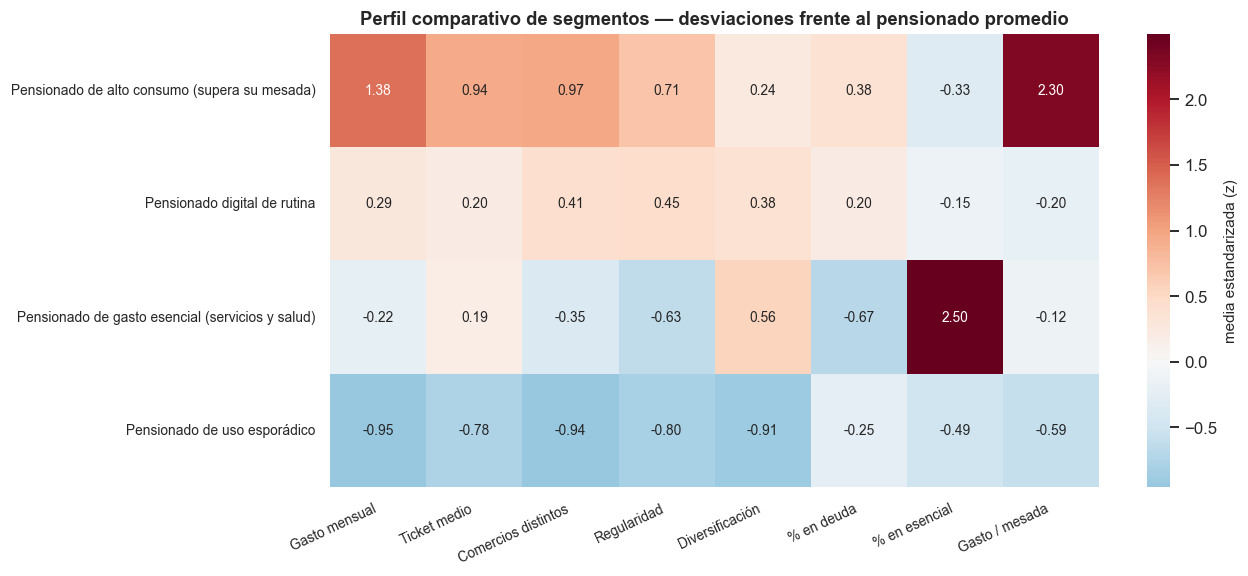

In [17]:
ETIQUETAS = {"gasto_mensual_medio": "Gasto mensual", "ticket_medio": "Ticket medio",
             "n_comercios": "Comercios distintos", "regularidad": "Regularidad",
             "diversificacion": "Diversificación", "share_deuda": "% en deuda",
             "share_esencial": "% en esencial", "tasa_consumo": "Gasto / mesada"}
ORDEN_SEG = perfil_nombrado.sort_values("gasto_mensual", ascending=False).index

Xstd = pd.DataFrame(StandardScaler().fit_transform(X), columns=FEATURES)
Xstd["segmento"] = F["segmento"].to_numpy()
heat = Xstd.groupby("segmento").mean().loc[ORDEN_SEG].rename(columns=ETIQUETAS)
fig, ax = plt.subplots(figsize=(12, 0.75 * len(heat) + 2.4))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            annot_kws={"size": 9}, cbar_kws={"label": "media estandarizada (z)"})
ax.set_title("Perfil comparativo de segmentos — desviaciones frente al pensionado promedio")
ax.set_ylabel(""); ax.tick_params(axis="x", rotation=25, labelsize=9)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)
for t in ax.get_xticklabels():
    t.set_ha("right")
plt.tight_layout(); plt.show()

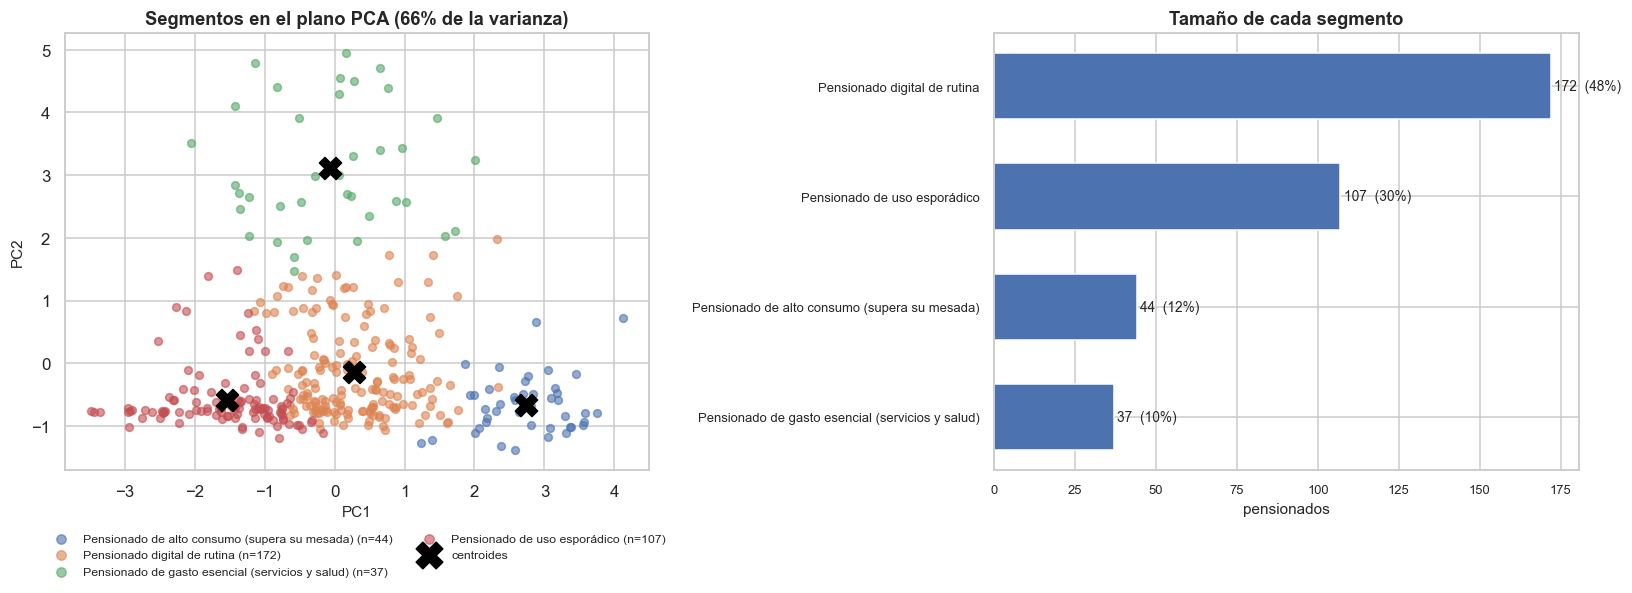

In [18]:
pca = PCA(n_components=2, random_state=SEMILLA).fit(Xs)
proj = pca.transform(Xs)
centros = pca.transform(modelo_kmeans.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
for i, seg in enumerate(ORDEN_SEG):
    m = F["segmento"].to_numpy() == seg
    axes[0].scatter(proj[m, 0], proj[m, 1], s=26, alpha=.6, label=f"{seg} (n={m.sum()})")
axes[0].scatter(centros[:, 0], centros[:, 1], s=210, c="black", marker="X", label="centroides")
axes[0].set_title(f"Segmentos en el plano PCA ({pca.explained_variance_ratio_.sum():.0%} de la varianza)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(fontsize=8, markerscale=1.2, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)

tam = F["segmento"].value_counts().sort_values()
axes[1].barh(tam.index, tam.values, color=AZUL, height=0.6)
axes[1].set_title("Tamaño de cada segmento")
axes[1].set_xlabel("pensionados")
for i, v in enumerate(tam.values):
    axes[1].text(v + 1, i, f"{v:,}  ({v/len(F)*100:.0f}%)", va="center", fontsize=9)
axes[1].tick_params(labelsize=8.5)
plt.tight_layout(); plt.show()

### 7.1 · Composición del gasto por segmento

**Objetivo técnico.** Ver en qué se diferencia realmente el bolsillo de cada segmento, en pesos y en
proporción. Es la vista que traduce el cluster a una conversación comercial.

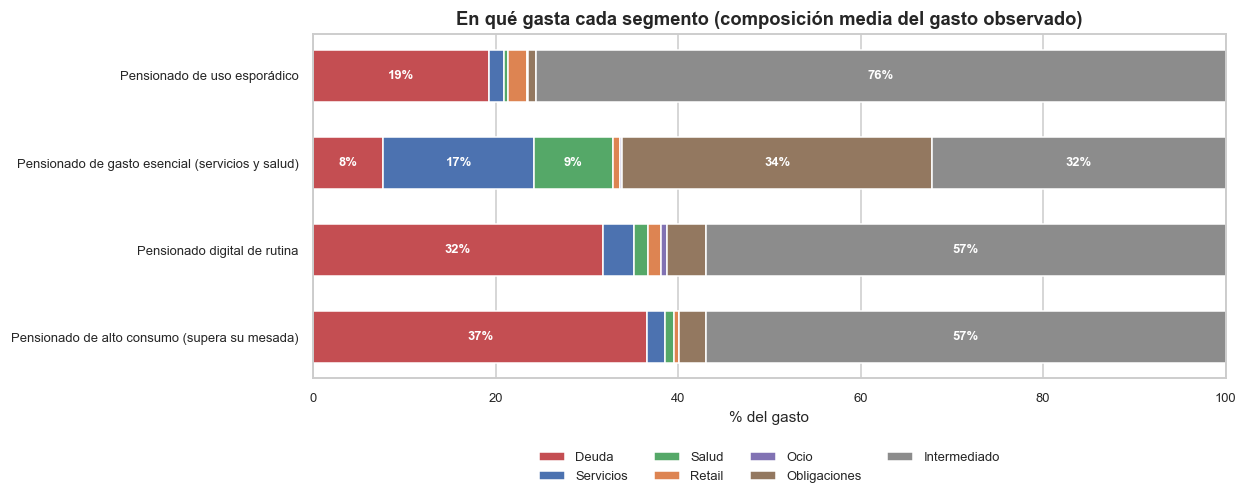

,Deuda,Servicios,Salud,Retail,Ocio,Obligaciones,Intermediado
segmento,,,,,,,
Pensionado de alto consumo (supera su mesada),36.60,1.90,1.10,0.50,0.10,2.90,56.90
Pensionado digital de rutina,31.70,3.40,1.60,1.40,0.60,4.30,56.90
Pensionado de gasto esencial (servicios y salud),7.70,16.50,8.60,0.80,0.20,34.00,32.10
Pensionado de uso esporádico,19.30,1.60,0.40,2.10,0.00,0.90,75.60


In [19]:
bloques = ["share_deuda", "share_servicios", "share_salud", "share_retail",
           "share_ocio", "share_obligaciones", "share_intermediado"]
mix = (F.groupby("segmento")[bloques].mean() * 100).loc[
    perfil_nombrado.sort_values("gasto_mensual", ascending=False).index]
mix.columns = [c.replace("share_", "").capitalize() for c in mix.columns]

fig, ax = plt.subplots(figsize=(11.5, 0.7 * len(mix) + 2))
izquierda = np.zeros(len(mix))
paleta = [ROJO, AZUL, VERDE, NARANJA, MORADO, "#937860", GRIS]
for color, col in zip(paleta, mix.columns):
    ax.barh(mix.index, mix[col], left=izquierda, color=color, label=col, height=0.6)
    for i, (v, iz) in enumerate(zip(mix[col], izquierda)):
        if v >= 7:
            ax.text(iz + v / 2, i, f"{v:.0f}%", ha="center", va="center", fontsize=8.5,
                    color="white", fontweight="bold")
    izquierda += mix[col].to_numpy()
ax.set_title("En qué gasta cada segmento (composición media del gasto observado)")
ax.set_xlabel("% del gasto"); ax.set_xlim(0, 100)
ax.legend(ncol=4, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.18))
ax.tick_params(labelsize=8.5)
plt.tight_layout(); plt.show()
display(mix.round(1))

### 7.2 · Lectura para cada empresa objetivo

**Objetivo técnico.** Cruzar los segmentos con las dos dimensiones comerciales que el caso de uso pide:
el **pagador de la mesada** (Colpensiones, Porvenir, aseguradoras) y la **penetración de las entidades
objetivo** de banca y retail.

pagador_mesada,Aseguradora (renta vitalicia),Colfondos,Colpensiones,Consorcio FOPEP,Empleador / otro pagador,Fondo público / especial,Porvenir,Protección,Skandia
segmento,,,,,,,,,
Pensionado de alto consumo (supera su mesada),29.50,6.80,25.00,9.10,25.00,0.00,0.00,2.30,2.30
Pensionado digital de rutina,28.50,2.90,33.10,7.00,18.00,0.60,5.20,3.50,1.20
Pensionado de gasto esencial (servicios y salud),16.20,2.70,29.70,10.80,29.70,0.00,8.10,2.70,0.00
Pensionado de uso esporádico,25.20,6.50,30.80,4.70,21.50,0.90,7.50,2.80,0.00


,personas,caja_compensacion_pct,retail_pct,banca_pct,share_objetivo_pct,gasto_objetivo_total
segmento,,,,,,
Pensionado de alto consumo (supera su mesada),44,18.20,4.50,40.90,6.30,"137,878,319.00"
Pensionado digital de rutina,172,10.50,5.20,28.50,2.90,"130,155,269.00"
Pensionado de gasto esencial (servicios y salud),37,8.10,5.40,8.10,1.60,"2,746,471.00"
Pensionado de uso esporádico,107,0.90,0.90,6.50,0.30,"1,370,453.00"


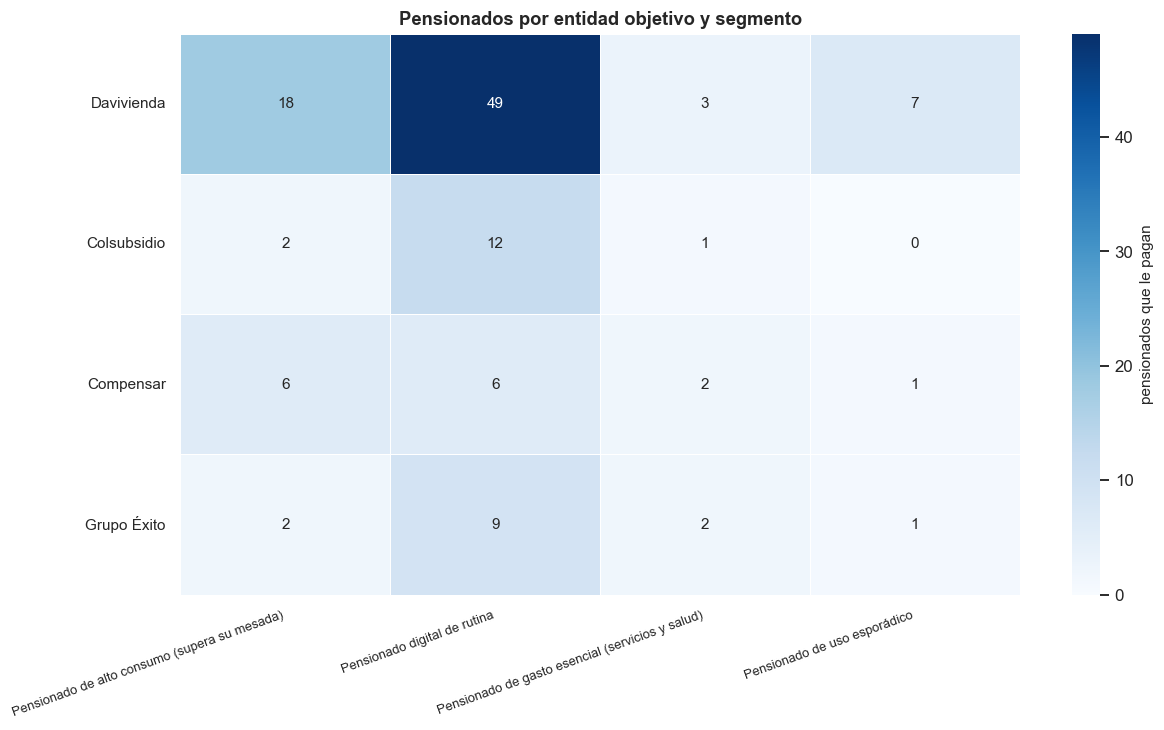

In [20]:
comp_pagador = (pd.crosstab(F["segmento"], F["pagador_mesada"], normalize="index") * 100).round(1)
display(comp_pagador.loc[perfil_nombrado.sort_values("gasto_mensual", ascending=False).index])

penetracion = F.groupby("segmento").agg(
    personas=("person_id", "size"),
    caja_compensacion_pct=("usa_caja_compensacion", lambda s: round(s.mean() * 100, 1)),
    retail_pct=("usa_retail_objetivo", lambda s: round(s.mean() * 100, 1)),
    banca_pct=("usa_banca_objetivo", lambda s: round(s.mean() * 100, 1)),
    share_objetivo_pct=("share_entidades_objetivo", lambda s: round(s.mean() * 100, 1)),
    gasto_objetivo_total=("gasto_entidades_objetivo", "sum"),
).loc[perfil_nombrado.sort_values("gasto_mensual", ascending=False).index]
display(penetracion)

detalle_obj = (pse_pens[pse_pens["entidad_objetivo"] != "No objetivo"]
               .merge(F[["person_id", "segmento"]], on="person_id", how="inner")
               .groupby(["entidad_objetivo", "segmento"])["person_id"].nunique().unstack(fill_value=0)
               .reindex(columns=ORDEN_SEG, fill_value=0))
detalle_obj = detalle_obj.loc[detalle_obj.sum(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(11.5, 0.85 * len(detalle_obj) + 3.4))
sns.heatmap(detalle_obj, annot=True, fmt="d", cmap="Blues", ax=ax, linewidths=.5,
            annot_kws={"size": 10}, cbar_kws={"label": "pensionados que le pagan"})
ax.set_title("Pensionados por entidad objetivo y segmento")
ax.set_xlabel(""); ax.set_ylabel("")
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.tick_params(axis="x", rotation=20, labelsize=8.5)
for t in ax.get_xticklabels():
    t.set_ha("right")
plt.tight_layout(); plt.show()

### 7.3 · Lectura de negocio y acción comercial

| Segmento | Qué lo define | Quién lo compra | Acción |
|---|---|---|---|
| **Alto consumo (supera su mesada)** | Gasta ~5× la mesada que declara, con la mayor frecuencia, el mayor ticket y un tercio del gasto en servicio de deuda | Banca (Davivienda, Bancolombia) · Retail (Grupo Éxito) | Es el segmento de **mayor valor y mayor riesgo a la vez**: cupo sobre ingreso verificado, pero con monitoreo de sobreendeudamiento. Investigar el origen del gasto por encima de la mesada (ingreso adicional o crédito) antes de ampliar exposición |
| **Digital de rutina** | El grueso de la base: gasto mensual estable, repartido entre varios comercios, con carga de deuda moderada | Banca · Cajas de compensación | Débito automático y recaudo unificado; up-sell de bajo riesgo. Es la masa sobre la que se construye volumen |
| **Gasto esencial (servicios y salud)** | Concentra el gasto en servicios públicos, salud y obligaciones; prácticamente sin deuda; el más diversificado | Cajas de compensación (Compensar, Colsubsidio) · aseguradoras | Planes complementarios de salud, bienestar del adulto mayor, convenios de farmacia. Perfil conservador y de bajo riesgo |
| **Uso esporádico** | Poco gasto, pocos comercios, la mitad de los meses sin actividad y tres cuartas partes del gasto intermediado | Todos, a bajo costo | Digitalización asistida y activación. **Ojo:** puede no ser un pensionado de bajo consumo sino un pensionado que consume fuera de este canal |

**Bandera transversal — `en_riesgo_desconexion`.** Un cuarto de los segmentos "gasto esencial" y "uso
esporádico" lleva 3 meses o más sin actividad, frente a menos del 5% en los dos segmentos activos. No es un
segmento aparte sino una **alerta operativa** dentro de cada uno.

**Para las AFP (Colpensiones, Porvenir).** El modelo muestra qué pasa con la mesada **después** de pagarla:
qué proporción se va en servicio de deuda y qué fracción de pensionados gasta por encima de su mesada
declarada. Colpensiones concentra alrededor de un tercio de cada segmento —su base es transversal, no
específica—, así que la segmentación por consumo le aporta lo que la afiliación no le dice: quién está
tensionando su ingreso. Es la base de un programa de educación financiera dirigido.

**Para la banca (Bancolombia, Davivienda).** La penetración por PSE crece de forma monótona con la
intensidad de consumo (del 6,5% en el segmento esporádico al 41% en el de alto consumo): el recaudo digital
ya identifica al pensionado valioso sin necesidad de un modelo de riesgo adicional.

**Para el retail (Grupo Éxito, Cencosud).** El dato duro es la **ausencia**: la penetración del retail
objetivo no pasa del 5% en ningún segmento y Cencosud no aparece. La oportunidad no está en optimizar este
canal sino en llegar vía **caja de compensación o banco**, que ya tienen la relación de recaudo recurrente
con este segmento.

## 8 · Exportación de artefactos

**Objetivo técnico.** Dejar el modelo utilizable fuera del notebook. Se guardan tres cosas:

1. **El modelo** (`.joblib`): un `Pipeline` de scikit-learn (escalador + K-Means) junto con todo lo
   necesario para reproducir el preprocesamiento sobre datos nuevos — lista de variables, cuáles llevan
   `log1p`, los límites de winsorización y el mapa `cluster → segmento`.
2. **El dataset segmentado** (`.parquet` + `.csv`) a nivel persona.
3. Una función `asignar_segmento()` que demuestra el uso en producción y se valida contra las etiquetas de
   entrenamiento.

In [21]:
DIR_MODELOS = ROOT / "Models" / "artifacts"
DIR_MODELOS.mkdir(parents=True, exist_ok=True)
DIR_DATOS = ROOT / "Data" / "processed"
DIR_DATOS.mkdir(parents=True, exist_ok=True)

pipeline = Pipeline([("escalado", ESCALADOR), ("kmeans", modelo_kmeans)])
artefacto = {
    "pipeline": pipeline,
    "features": FEATURES,
    "log_features": LOG_FEATURES,
    "limites_winsor": LIMITES,
    "mapa_segmentos": nombres,
    "metadata": {
        "modelo": "#101 Segmentación de pensionados por consumo",
        "caso_uso": 5,
        "sector": "Retail y Banca",
        "algoritmo": f"KMeans(k={K})",
        "semilla": SEMILLA,
        "ventana": VENTANA,
        "n_personas_entrenamiento": int(len(F)),
        "silueta": float(metricas_k.loc[K, "silueta"]),
        "davies_bouldin": float(metricas_k.loc[K, "davies_bouldin"]),
        "escalador": type(ESCALADOR).__name__,
    },
}
ruta_modelo = DIR_MODELOS / "caso05_modelo101_pensionados_kmeans.joblib"
joblib.dump(artefacto, ruta_modelo)

COLS_SALIDA = ["person_id", "cluster", "segmento", "pagador_mesada", "regimen_pension",
               "mesada_declarada", "gasto_total", "gasto_mensual_medio", "tasa_consumo",
               "n_pagos", "n_comercios", "ticket_medio", "meses_activos", "regularidad",
               "recencia_meses", "volatilidad_gasto", "hhi_mensual", "diversificacion",
               "share_deuda", "share_servicios", "share_salud", "share_retail", "share_ocio",
               "share_obligaciones", "share_intermediado", "ingreso_ach_mensual",
               "share_entidades_objetivo", "n_entidades_objetivo", "usa_caja_compensacion",
               "usa_retail_objetivo", "usa_banca_objetivo"]
salida = F[COLS_SALIDA].copy()
ruta_parquet = DIR_DATOS / "segmentos_pensionados.parquet"
ruta_csv = DIR_DATOS / "segmentos_pensionados.csv"
salida.to_parquet(ruta_parquet, index=False)
salida.to_csv(ruta_csv, index=False, encoding="utf-8-sig")

print(f"Modelo   : {ruta_modelo.relative_to(ROOT)}  ({ruta_modelo.stat().st_size/1024:,.0f} KB)")
print(f"Dataset  : {ruta_parquet.relative_to(ROOT)}  ({len(salida):,} filas x {salida.shape[1]} columnas)")
print(f"Dataset  : {ruta_csv.relative_to(ROOT)}")
display(salida.head(5))

Modelo   : Models\artifacts\caso05_modelo101_pensionados_kmeans.joblib  (4 KB)
Dataset  : Data\processed\segmentos_pensionados.parquet  (360 filas x 31 columnas)
Dataset  : Data\processed\segmentos_pensionados.csv


,person_id,cluster,segmento,pagador_mesada,regimen_pension,mesada_declarada,gasto_total,gasto_mensual_medio,tasa_consumo,n_pagos,n_comercios,ticket_medio,meses_activos,regularidad,recencia_meses,volatilidad_gasto,hhi_mensual,diversificacion,share_deuda,share_servicios,share_salud,share_retail,share_ocio,share_obligaciones,share_intermediado,ingreso_ach_mensual,share_entidades_objetivo,n_entidades_objetivo,usa_caja_compensacion,usa_retail_objetivo,usa_banca_objetivo
0,23200167****,3,Pensionado digital de rutina,Colpensiones,Prima media (RPM),"3,505,129.50","6,312,686.00","350,704.78",0.10,51.00,24,"123,778.16",18,1.00,0,1.42,0.16,0.37,0.01,0.01,0.00,0.02,0.00,0.22,0.74,"2,958,979.61",0.02,1.00,True,False,False
1,232004****,0,Pensionado de gasto esencial (servicios y salud),Colpensiones,Prima media (RPM),"4,112,232.00","85,081,674.45","4,726,759.69",1.15,368.00,38,"231,200.20",18,1.00,0,0.67,0.08,0.72,0.04,0.20,0.07,0.01,0.03,0.15,0.51,"1,626,388.89",0.00,1.00,False,True,False
2,23200456****,3,Pensionado digital de rutina,Colpensiones,Prima media (RPM),"1,376,050.00","6,482,113.21","648,211.32",0.47,25.00,7,"259,284.53",10,0.56,5,1.35,0.26,0.33,0.65,0.00,0.00,0.00,0.00,0.00,0.35,"1,554,918.60",0.03,1.00,True,False,False
3,23200807****,0,Pensionado de gasto esencial (servicios y salud),Colfondos,Ahorro individual (RAIS),"650,000.00","2,428,194.00","404,699.00",0.62,9.00,5,"269,799.33",6,0.33,0,0.72,0.24,0.32,0.00,0.00,0.00,0.00,0.00,0.32,0.68,0.00,0.42,1.00,True,False,False
4,23201147****,3,Pensionado digital de rutina,Colpensiones,Prima media (RPM),"579,999.00","11,808,216.00","787,214.40",1.36,52.00,15,"227,081.08",15,0.83,0,1.03,0.13,0.61,0.39,0.01,0.09,0.02,0.00,0.03,0.46,"2,485,566.67",0.00,0.00,False,False,False


In [22]:
def asignar_segmento(nuevos: pd.DataFrame, ruta=ruta_modelo) -> pd.Series:
    """Asigna el segmento a pensionados nuevos aplicando exactamente el mismo
    preprocesamiento del entrenamiento (winsorización -> log1p -> escalado -> K-Means)."""
    art = joblib.load(ruta)
    Z = nuevos[art["features"]].copy().astype(float)
    for col, (lo, hi) in art["limites_winsor"].items():
        Z[col] = Z[col].clip(lo, hi)
    for col in art["log_features"]:
        Z[col] = np.log1p(Z[col])
    etiquetas = art["pipeline"].predict(Z)
    return pd.Series([art["mapa_segmentos"][c] for c in etiquetas], index=nuevos.index,
                     name="segmento")


verificacion = asignar_segmento(F)
coincide = (verificacion.to_numpy() == F["segmento"].to_numpy()).mean()
print(f"Validación del artefacto: {coincide*100:.1f}% de coincidencia con las etiquetas de entrenamiento")
print("\nDistribución de segmentos exportada:")
print(salida["segmento"].value_counts().to_frame("personas")
      .assign(**{"%": (salida["segmento"].value_counts(normalize=True) * 100).round(1)}).to_string())

Validación del artefacto: 100.0% de coincidencia con las etiquetas de entrenamiento

Distribución de segmentos exportada:
                                                  personas     %
segmento                                                        
Pensionado digital de rutina                           172 47.80
Pensionado de uso esporádico                           107 29.70
Pensionado de alto consumo (supera su mesada)           44 12.20
Pensionado de gasto esencial (servicios y salud)        37 10.30


## 9 · Limitaciones, supuestos y próximos pasos

### 9.1 · Supuestos que condicionan el resultado
1. **La condición de pensionado se toma de PILA**, no de un proxy conductual. Es preciso pero conservador:
   un pensionado que no cotiza salud por esta vía (o cuya cotización quedó fuera del extracto) no aparece.
2. **La mesada se aproxima con el IBC de salud** de los meses en condición de pensionado. Es la definición
   correcta —se cotiza salud sobre la mesada— pero hereda cualquier error de reporte del pagador.
3. **El consumo se observa solo por PSE.** Efectivo, tarjeta presencial y débitos automáticos internos del
   banco no son visibles: todas las magnitudes de gasto son **cotas inferiores**.
4. **Llave de persona = cédula enmascarada**, con el riesgo de colisión documentado en el notebook 00.

### 9.2 · Limitaciones de los datos
- **Tamaño de la población**: el universo observable son cientos de pensionados, no miles. Los segmentos
  son **direccionales**; para llevarlos a campaña hace falta el extracto completo.
- **Truncamiento** de Transferencias y PSE en el tope de filas de Excel: los volúmenes son relativos.
- **Sin granularidad diaria**: el efecto "día de pago de la mesada" no es medible (§4.2).
- **Gasto intermediado**: la porción que pasa por pasarelas y comercios no clasificables acota lo que la
  composición del gasto puede explicar.
- **Sin ubicación**: no hay capa geográfica, así que el cruce *salario × ciudad × comercio* que pide el
  caso 5 queda incompleto por el lado de la ciudad.

### 9.3 · Próximos pasos, en orden de impacto
1. **Extracto completo y llave hasheada** — multiplica la población de pensionados y elimina el riesgo de
   colisión de identidad.
2. **Catálogo maestro de comercios con MCC** — convierte el gasto intermediado en gasto clasificado y
   permite medir de verdad la penetración del retail.
3. **Fecha de la transacción (día)** — habilita el análisis de ciclo de mesada, que es la señal más
   accionable para campañas.
4. **Cruzar con el modelo #46 (ciclo de vida financiero) y el #4 (CLV)** para una matriz
   *valor × etapa × consumo* del pensionado.
5. **Seguimiento longitudinal**: reejecutar trimestralmente y medir migración entre segmentos — la
   transición "de rutina" → "apalancado" es la alerta temprana de deterioro más valiosa para el negocio.